Data Preparation

In [98]:
# Data Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
  
   
DATA_DIR = 'uploads/'
print('Libraries loaded ')

Libraries loaded 


In [99]:
# Load EUA front-year settlement prices
eua = pd.read_csv(f'{DATA_DIR}eua_front_year.csv', parse_dates=['trade_date'])
print(f'Shape: {eua.shape}')
print(f'Date range: {eua.trade_date.min().date()} to {eua.trade_date.max().date()}')
print(f'Columns: {list(eua.columns)}')
eua.head(3)

Shape: (1331, 5)
Date range: 2021-01-04 to 2026-02-25
Columns: ['trade_date', 'maturity_date', 'settlement', 'volume', 'open_interest']


,trade_date,maturity_date,settlement,volume,open_interest
0,2021-01-04,2021-12-01,33.69,19317000.0,492100000.0
1,2021-01-05,2021-12-01,32.96,19391000.0,491970000.0
2,2021-01-06,2021-12-01,33.63,17381000.0,493675000.0


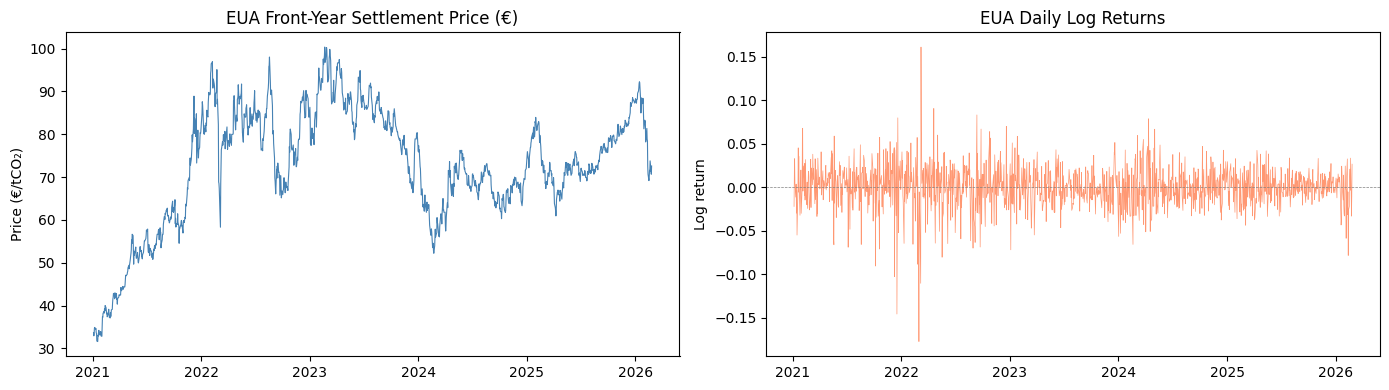

Log return stats:
count    1330.00000
mean        0.00058
std         0.02457
min        -0.17735
25%        -0.01201
50%         0.00094
75%         0.01485
max         0.16138
Name: r_EUA, dtype: float64


In [100]:
eua = eua.sort_values('trade_date').reset_index(drop=True)
eua['r_EUA'] = np.log(eua['settlement'] / eua['settlement'].shift(1))
# Plot: raw prices vs log returns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(eua['trade_date'], eua['settlement'], color='steelblue', linewidth=0.8)
axes[0].set_title('EUA Front-Year Settlement Price (€)', fontsize=12)
axes[0].set_ylabel('Price (€/tCO₂)')

axes[1].plot(eua['trade_date'], eua['r_EUA'], color='coral', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[1].set_title('EUA Daily Log Returns', fontsize=12)
axes[1].set_ylabel('Log return')
    
plt.tight_layout()
plt.show()

print(f'Log return stats:')
print(eua['r_EUA'].describe().round(5))

In [101]:
# 2. Load Energy Futures Price
# TTF Gas — the European natural gas benchmark. Gas vs coal generation affects how much CO₂ is emitted.
# API2 Coal — the seaborne thermal coal benchmark for Europe.
# Brent Crude — global oil benchmark. Captures broader energy/macro sentiment.
# German Baseload Power — the electricity price. Higher power prices mean more generation, more emissions, more EUA demand.

# TTF Gas
ttf = pd.read_csv(f'{DATA_DIR}ttf_front_month.csv', parse_dates=['trade_date'])
ttf = ttf[['trade_date', 'TTF_front_settlement']].rename(columns={'TTF_front_settlement': 'TTF'})
ttf = ttf.sort_values('trade_date')
ttf['r_TTF'] = np.log(ttf['TTF'] / ttf['TTF'].shift(1))
# Coal
coal = pd.read_csv(f'{DATA_DIR}coal_front_month.csv', parse_dates=['trade_date'])
coal = coal[['trade_date', 'Coal_front_settlement']].rename(columns={'Coal_front_settlement': 'Coal'})
coal = coal.sort_values('trade_date')
coal['r_Coal'] = np.log(coal['Coal'] / coal['Coal'].shift(1))    
# Brent Crude
brent = pd.read_csv(f'{DATA_DIR}brent_crude_front_month.csv', parse_dates=['trade_date'])
brent = brent[['trade_date', 'Brent Crude_front_settlement']].rename(columns={'Brent Crude_front_settlement': 'Brent'})
brent = brent.sort_values('trade_date')
brent['r_Brent'] = np.log(brent['Brent'] / brent['Brent'].shift(1))
# German Power
power = pd.read_csv(f'{DATA_DIR}german_power_front_month.csv', parse_dates=['trade_date'])
power = power[['trade_date', 'German Power_front_settlement']].rename(columns={'German Power_front_settlement': 'Power'})
power = power.sort_values('trade_date')
power['r_Power'] = np.log(power['Power'] / power['Power'].shift(1))
    
print('Energy futures loaded:')
for name, df in [('TTF', ttf), ('Coal', coal), ('Brent', brent), ('Power', power)]:
    print(f'  {name}: {len(df)} rows, {df.iloc[:,1].isna().sum()} nulls in price')

Energy futures loaded:
  TTF: 1331 rows, 0 nulls in price
  Coal: 1331 rows, 0 nulls in price
  Brent: 1331 rows, 0 nulls in price
  Power: 1310 rows, 0 nulls in price


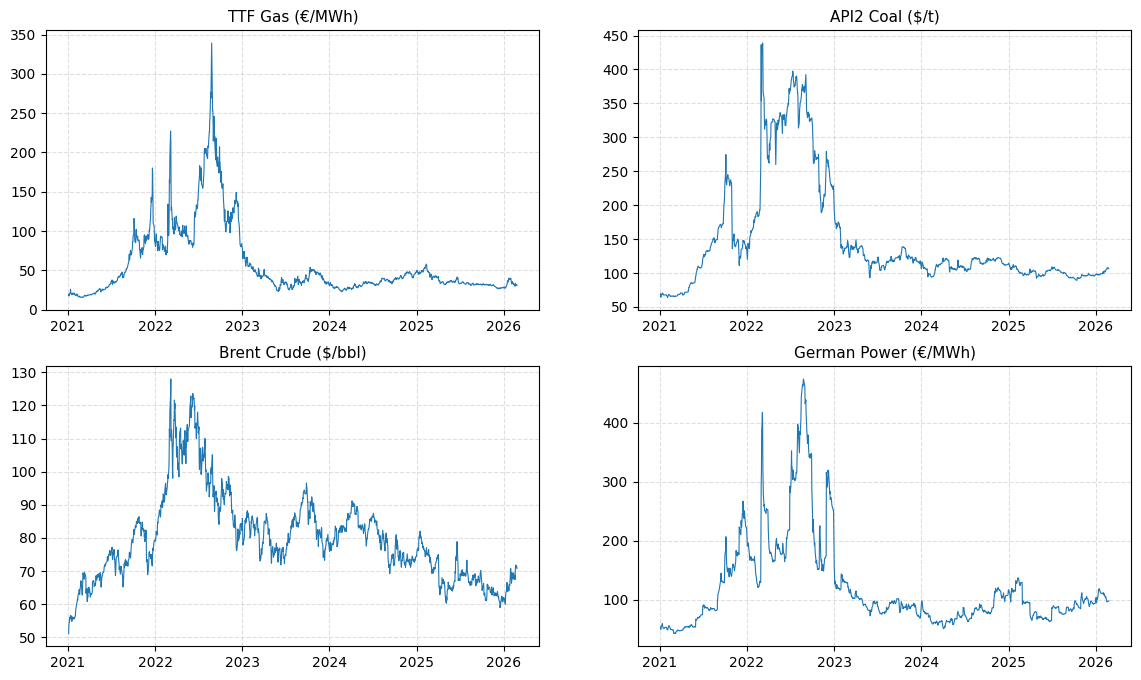

In [102]:
# Visualise all energy prices
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
   
plots = [
    ('TTF Gas (€/MWh)', ttf, 'TTF'),
    ('API2 Coal ($/t)', coal, 'Coal'),
    ('Brent Crude ($/bbl)', brent, 'Brent'),
    ('German Power (€/MWh)', power, 'Power')
]

for ax, (name, df, col) in zip(axes.flat, plots):
    ax.plot(df['trade_date'], df[col], linewidth=0.8)
    ax.set_title(name, fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)


CDS: 1175 rows, range 2021-01-04 to 2026-02-25
CSS: 1175 rows, range 2021-01-04 to 2026-02-25


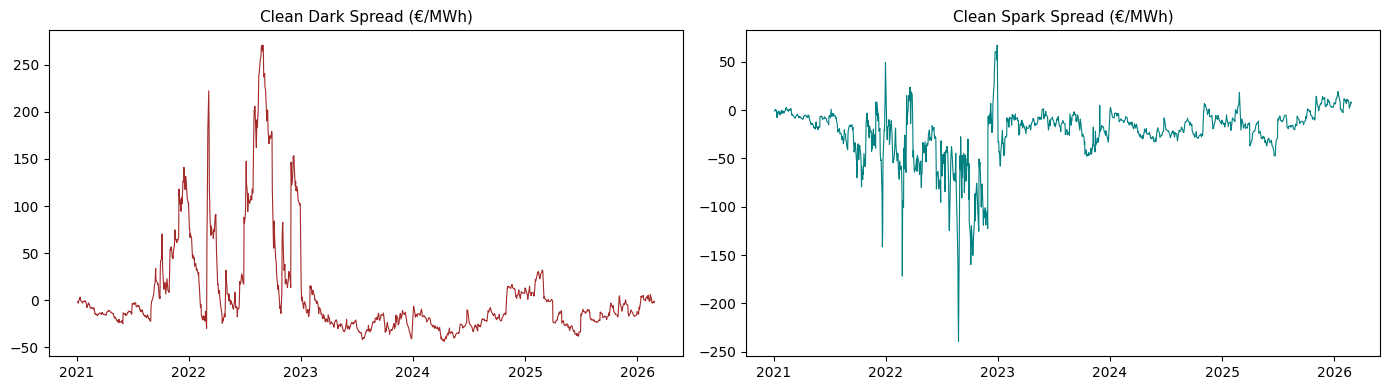

In [103]:
# 3. Load Energy Spreads
# Dark Spread
cds = pd.read_csv(f'{DATA_DIR}clean_dark_spread_data.csv', parse_dates=['date'])
cds = cds[['date', 'clean_dark_value']].rename(columns={'date': 'trade_date', 'clean_dark_value': 'CDS'})
cds = cds.sort_values('trade_date')
cds['d_CDS'] = cds['CDS'].diff()  

    
# Spark Spread
css = pd.read_csv(f'{DATA_DIR}clean_spark_spread_data.csv', parse_dates=['date'])
css = css[['date', 'clean_spark_value']].rename(columns={'date': 'trade_date', 'clean_spark_value': 'CSS'})
css = css.sort_values('trade_date')
css['d_CSS'] = css['CSS'].diff()  


print(f'CDS: {len(cds)} rows, range {cds.trade_date.min().date()} to {cds.trade_date.max().date()}')
print(f'CSS: {len(css)} rows, range {css.trade_date.min().date()} to {css.trade_date.max().date()}')

# Plot spreads
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cds['trade_date'], cds['CDS'], linewidth=0.8, color='brown')
axes[0].set_title('Clean Dark Spread (€/MWh)', fontsize=11)
axes[1].plot(css['trade_date'], css['CSS'], linewidth=0.8, color='teal')
axes[1].set_title('Clean Spark Spread (€/MWh)', fontsize=11)
plt.tight_layout()
plt.show()

In [104]:
# Consolidated Database


db = eua[['trade_date', 'settlement', 'r_EUA']].rename(columns={'settlement': 'EUA_price'})

# energy futures
db = db.merge(ttf[['trade_date', 'TTF', 'r_TTF']], on='trade_date', how='inner')
db = db.merge(coal[['trade_date', 'Coal', 'r_Coal']], on='trade_date', how='inner')
db = db.merge(brent[['trade_date', 'Brent', 'r_Brent']], on='trade_date', how='inner')
db = db.merge(power[['trade_date', 'Power', 'r_Power']], on='trade_date', how='inner')

# spreads 
db = db.merge(cds[['trade_date', 'CDS', 'd_CDS']], on='trade_date', how='left')
db = db.merge(css[['trade_date', 'CSS', 'd_CSS']], on='trade_date', how='left')
   
db = db.sort_values('trade_date').reset_index(drop=True)
    
print(f'Consolidated DB shape: {db.shape}')
print(f'Date range: {db.trade_date.min().date()} to {db.trade_date.max().date()}')
print(f'Null counts:')
print(db.isnull().sum())
print(f'First few rows:')
db.head()

Consolidated DB shape: (1310, 15)
Date range: 2021-01-04 to 2026-02-25
Null counts:
trade_date      0
EUA_price       0
r_EUA           1
TTF             0
r_TTF           1
Coal            0
r_Coal          1
Brent           0
r_Brent         1
Power           0
r_Power         1
CDS           135
d_CDS         136
CSS           135
d_CSS         136
dtype: int64
First few rows:


,trade_date,EUA_price,r_EUA,TTF,r_TTF,Coal,r_Coal,Brent,r_Brent,Power,r_Power,CDS,d_CDS,CSS,d_CSS
0,2021-01-04,33.69,NaN,19.844,NaN,69.30,NaN,51.09,NaN,52.98,NaN,-1.515359,NaN,-1.060765,NaN
1,2021-01-05,32.96,-0.021906,18.007,-0.097141,64.90,-0.065597,53.60,0.047960,49.35,-0.070977,-3.044269,-1.528910,-0.751747,0.309018
2,2021-01-06,33.63,0.020124,17.564,-0.024909,64.25,-0.010066,54.30,0.012975,49.93,0.011684,-2.831825,0.212444,0.467639,1.219386
3,2021-01-07,34.76,0.033049,19.303,0.094409,66.60,0.035923,54.38,0.001472,52.88,0.057403,-1.654952,1.176873,-0.476291,-0.943930
4,2021-01-08,34.92,0.004592,20.118,0.041354,68.50,0.028129,55.99,0.029177,55.43,0.047096,0.119538,1.774489,0.384816,0.861107


In [105]:
# Stationarity Testing (ADF Test)

# The Augmented Dickey-Fuller (ADF) test checks whether a time series has a unit root (i.e., is non-stationary).
# Null hypothesis: the series has a unit root (non-stationary)
# If p-value < 0.05, we reject the null → series IS stationary
# If p-value ≥ 0.05, we fail to reject → series is NOT stationary

def adf_test(series, name):
    clean = series.dropna()
    if len(clean) < 20:
        return {'Series': name, 'ADF Stat': np.nan, 'p-value': np.nan, 'Stationary?': '?'}
    result = adfuller(clean, autolag='AIC')
    return {
    'Series': name,
    'ADF Stat': round(result[0], 3),
    'p-value': round(result[1], 4),
    'Stationary?': 'Yes' if result[1] < 0.05 else 'No'
    }

# raw levels and stationary transforms
tests = []
  
# Raw prices 
for col in ['EUA_price', 'TTF', 'Coal', 'Brent', 'Power', 'CDS', 'CSS']:
    tests.append(adf_test(db[col], f'{col} (level)'))

# Stationary transforms
for col in ['r_EUA', 'r_TTF', 'r_Coal', 'r_Brent', 'r_Power', 'd_CDS', 'd_CSS']:
    tests.append(adf_test(db[col], f'{col} (return/diff)'))

adf_results = pd.DataFrame(tests)
print('ADF Stationarity Test Results')
print(adf_results.to_string(index=False))

ADF Stationarity Test Results
               Series  ADF Stat  p-value Stationary?
    EUA_price (level)    -3.175   0.0215         Yes
          TTF (level)    -2.164   0.2197          No
         Coal (level)    -1.929   0.3186          No
        Brent (level)    -2.344   0.1583          No
        Power (level)    -2.500   0.1154          No
          CDS (level)    -3.334   0.0134         Yes
          CSS (level)    -3.404   0.0108         Yes
  r_EUA (return/diff)   -16.840   0.0000         Yes
  r_TTF (return/diff)   -16.264   0.0000         Yes
 r_Coal (return/diff)   -16.616   0.0000         Yes
r_Brent (return/diff)   -17.479   0.0000         Yes
r_Power (return/diff)   -30.655   0.0000         Yes
  d_CDS (return/diff)    -7.699   0.0000         Yes
  d_CSS (return/diff)   -10.850   0.0000         Yes


In [106]:
# Lagged Features (Day-Ahead Constraint)
# Create lagged features 
# Lagged returns (for AR(1) and energy futures models)

db['lag_r_EUA'] = db['r_EUA'].shift(1)    # Yesterday's EUA return
db['lag_r_TTF'] = db['r_TTF'].shift(1)    # Yesterday's TTF return
db['lag_r_Coal'] = db['r_Coal'].shift(1)  # Yesterday's Coal return
db['lag_r_Brent'] = db['r_Brent'].shift(1) # Yesterday's Brent return
db['lag_r_Power'] = db['r_Power'].shift(1) # Yesterday's Power return
    
# Lagged spread changes
db['lag_d_CDS'] = db['d_CDS'].shift(1)    # Yesterday's CDS change
db['lag_d_CSS'] = db['d_CSS'].shift(1)    # Yesterday's CSS change

print('Lagged features created:')
print(db[['trade_date', 'r_EUA', 'lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal']].head(5))
print(f'Note: Row 0 has NaN for r_EUA (no prior price), Row 1 has NaN for lag_r_EUA (shift).')

Lagged features created:
  trade_date     r_EUA  lag_r_EUA  lag_r_TTF  lag_r_Coal
0 2021-01-04       NaN        NaN        NaN         NaN
1 2021-01-05 -0.021906        NaN        NaN         NaN
2 2021-01-06  0.020124  -0.021906  -0.097141   -0.065597
3 2021-01-07  0.033049   0.020124  -0.024909   -0.010066
4 2021-01-08  0.004592   0.033049   0.094409    0.035923
Note: Row 0 has NaN for r_EUA (no prior price), Row 1 has NaN for lag_r_EUA (shift).


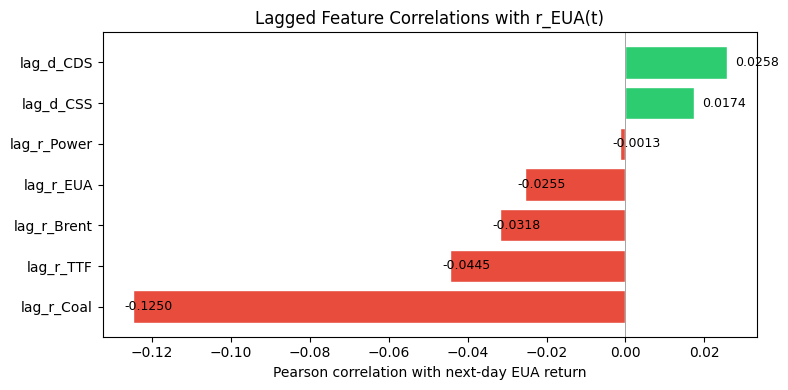

Key observation: lag_r_Coal has the strongest correlation — consistent with the report.


In [107]:
# Correlation Overview
# Correlation of lagged features with target
lag_cols = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']
target = 'r_EUA'

corrs = db[lag_cols + [target]].corr()[target].drop(target).sort_values()
  
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, edgecolor='white')
ax.set_xlabel('Pearson correlation with next-day EUA return')
ax.set_title('Lagged Feature Correlations with r_EUA(t)', fontsize=12)
ax.axvline(0, color='grey', linewidth=0.5)
 
for i, (idx, val) in enumerate(corrs.items()):
    ax.text(val + 0.002 * np.sign(val), i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
 
print('Key observation: lag_r_Coal has the strongest correlation — consistent with the report.')


In [108]:
# Save
output_path = 'consolidated_db.csv'
db.to_csv(output_path, index=False)
   
print(f'Saved to {output_path}')
print(f'Shape: {db.shape}')
print(f'Columns: {list(db.columns)}')


Saved to consolidated_db.csv
Shape: (1310, 22)
Columns: ['trade_date', 'EUA_price', 'r_EUA', 'TTF', 'r_TTF', 'Coal', 'r_Coal', 'Brent', 'r_Brent', 'Power', 'r_Power', 'CDS', 'd_CDS', 'CSS', 'd_CSS', 'lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']


Day-Ahead Prediction — DA_0 and DA_1
DA_0: AR(1) baseline — can yesterday's EUA return predict today's?
DA_1: Add energy futures — does knowing yesterday's gas/coal/oil/power returns help?
  
Key concepts
OLS (Ordinary Least Squares): the simplest regression — find the straight line (or plane) that minimises the sum of squared errors. Well-understood, easy to interpret, and a solid baseline before trying anything fancier.

Train/test split: we use the first 80% of data for fitting (in-sample) and the last 20% for evaluation (out-of-sample). We split chronologically — never randomly — because time series data has temporal dependence.

Win Rate: the % of days where our model correctly predicts the *direction* (up or down) of the EUA return. 50% = coin flip. Even 53% is meaningful in trading.


In [109]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm

db = pd.read_csv('consolidated_db.csv', parse_dates=['trade_date'])
print(f'Loaded: {db.shape[0]} rows, {db.shape[1]} columns')
print(f'Date range: {db.trade_date.min().date()} to {db.trade_date.max().date()}')

Loaded: 1310 rows, 22 columns
Date range: 2021-01-04 to 2026-02-25


In [110]:
# Helper functions

def prepare_data(db, target, features, dropna=True):
    cols = [target] + features + ['trade_date']
    data = db[cols].copy()
    if dropna:
        data = data.dropna().reset_index(drop=True)
        return data
    
def train_test_split_ts(data, train_frac=0.8):
    n = len(data)
    split = int(n * train_frac)
    return data.iloc[:split].copy(), data.iloc[split:].copy()

def fit_ols(train, target, features):
    # Fit OLS regression using statsmodels.
    # Why statsmodels instead of sklearn? statsmodels gives us p-values, t-stats, confidence intervals,and diagnostic tests — essential for understanding what's significant.
    X = sm.add_constant(train[features]) 
    y = train[target]
    model = sm.OLS(y, X).fit()
    return model
    
def evaluate_model(model, train, test, target, features, model_name):
    """
    Compute IS and OOS metrics, print a clean summary.
    Returns a tuple: (results_dict, pred_test_series).
    """
    X_train = sm.add_constant(train[features])
    X_test  = sm.add_constant(test[features])
    
    y_train = train[target]
    y_test  = test[target]
    
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)
    
    # Metrics
    is_r2    = model.rsquared
    adj_r2   = model.rsquared_adj
    oos_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    oos_mae  = mean_absolute_error(y_test, pred_test)
    
    # Win Rate: correct direction prediction
    correct_direction = (np.sign(pred_test) == np.sign(y_test))
    win_rate = correct_direction.mean()
    
    results = {
        'Model': model_name,
        'n_train': len(train),
        'n_test': len(test),
        'IS_R2': is_r2,
        'Adj_R2': adj_r2,
        'OOS_RMSE': oos_rmse,
        'OOS_MAE': oos_mae,
        'Win_Rate': win_rate
    }
    
    print(f'\n{"=" * 60}')
    print(f'  {model_name}')
    print(f'{"=" * 60}')
    print(f'  Train: {len(train)} days | Test: {len(test)} days')
    print(f'  IS R²:     {is_r2:.4f}')
    print(f'  Adj R²:    {adj_r2:.4f}')
    print(f'  OOS RMSE:  {oos_rmse:.5f}')
    print(f'  OOS MAE:   {oos_mae:.5f}')
    wr_comment = "better than coin flip" if win_rate > 0.50 else "no better than guessing"
    print(f'  Win Rate:  {win_rate:.2%}  ({wr_comment})')
    print(f'{"=" * 60}')
    
    return results, pred_test

def plot_diagnostics(model, train, test, target, features, pred_test, model_name):
    
    X_train = sm.add_constant(train[features])
    pred_train = model.predict(X_train)
    residuals = train[target] - pred_train
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
    # 1. In-sample fit
    axes[0].plot(train['trade_date'], train[target], alpha=0.5, linewidth=0.5, label='Actual')
    axes[0].plot(train['trade_date'], pred_train, alpha=0.7, linewidth=0.5, color='red', label='Fitted')
    axes[0].set_title(f'{model_name} — In-Sample Fit', fontsize=11)
    axes[0].legend(fontsize=9)
    
    # 2. OOS predictions vs actual
    axes[1].plot(test['trade_date'], test[target], alpha=0.5, linewidth=0.5, label='Actual')
    axes[1].plot(test['trade_date'], pred_test, alpha=0.7, linewidth=0.5, color='red', label='Predicted')
    axes[1].set_title(f'{model_name} — Out-of-Sample', fontsize=11)
    axes[1].legend(fontsize=9)
    
    # 3. Residual distribution
    axes[2].hist(residuals, bins=50, edgecolor='white', alpha=0.7, color='steelblue')
    axes[2].axvline(0, color='red', linewidth=1, linestyle='--')
    axes[2].set_title(f'{model_name} — IS Residuals', fontsize=11)
    axes[2].set_xlabel('Residual')
   
plt.tight_layout()
plt.show()

def f_test_nested(model_restricted, model_unrestricted, n_obs):
    """
    F-test for nested OLS models.
    
    Tests whether the EXTRA features in the unrestricted model are
    *jointly* significant — i.e., do they add explanatory power beyond
    what the restricted model already captures?
    
    H0: the extra coefficients are all zero (restricted model is enough)
    H1: at least one extra coefficient is non-zero (unrestricted is better)
    
    Returns: (f_stat, p_value, df1, df2)
    """
    rss_r = model_restricted.ssr   # Residual sum of squares — restricted
    rss_u = model_unrestricted.ssr # Residual sum of squares — unrestricted
    
    p = model_unrestricted.df_model - model_restricted.df_model  # extra params
    k = model_unrestricted.df_model + 1  # total params in unrestricted (incl. const)
    n = n_obs
    
    f_stat = ((rss_r - rss_u) / p) / (rss_u / (n - k))
    p_value = 1 - stats.f.cdf(f_stat, p, n - k)
    
    print(f'\n  F-test: F({p}, {n-k}) = {f_stat:.4f},  p = {p_value:.4f}')
    if p_value < 0.05:
        print(f'  → Reject H0 at 5%: the extra features ARE jointly significant.')
    else:
        print(f'  → Cannot reject H0: the extra features are NOT jointly significant.')
    
    return f_stat, p_value, p, n - k

def residual_diagnostics(model, model_name):
    """
    Run Durbin-Watson (autocorrelation) and Breusch-Pagan (heteroscedasticity)
    tests on the in-sample residuals.
    
    Durbin-Watson:
      Range 0 to 4.  Close to 2 = no autocorrelation (good).
      Below 1.5 = positive autocorrelation.  Above 2.5 = negative.
    
    Breusch-Pagan:
      Tests if residual variance depends on X.
      p < 0.05 = heteroscedastic (variance changes over time — not ideal).
    """
    from statsmodels.stats.stattools import durbin_watson
    from statsmodels.stats.diagnostic import het_breuschpagan
    
    resid = model.resid
    dw = durbin_watson(resid)
    
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, model.model.exog)
    
    print(f'\n  Residual diagnostics for {model_name}:')
    print(f'    Durbin-Watson:  {dw:.3f}  ', end='')
    if 1.5 < dw < 2.5:
        print('(OK — no strong autocorrelation)')
    else:
        print('(WARNING — possible autocorrelation)')
    print(f'    Breusch-Pagan:  stat={bp_stat:.3f}, p={bp_p:.4f}  ', end='')
    if bp_p > 0.05:
        print('(OK — homoscedastic)')
    else:
        print('(heteroscedastic — consider robust SE)')
    
    return dw, bp_stat, bp_p

print('Helper functions defined')

<Figure size 1200x400 with 0 Axes>

Helper functions defined


In [111]:
# Model DA_0: AR(1) Baseline
# DA_0: AR(1)
target = 'r_EUA'
features_da0 = ['lag_r_EUA']
  
# Prepare data: drop rows with NaN (first 2 rows due to return + lag)
data_da0 = prepare_data(db, target, features_da0)
train_da0, test_da0 = train_test_split_ts(data_da0)
# Fit the model
model_da0 = fit_ols(train_da0, target, features_da0)
print(model_da0.summary())


                            OLS Regression Results                            
Dep. Variable:                  r_EUA   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.001
Date:                Fri, 29 May 2026   Prob (F-statistic):              0.317
Time:                        00:15:54   Log-Likelihood:                 2325.3
No. Observations:                1046   AIC:                            -4647.
Df Residuals:                    1044   BIC:                            -4637.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      1.127      0.2


  DA_0: AR(1)
  Train: 1046 days | Test: 262 days
  IS R²:     0.0010
  Adj R²:    0.0000
  OOS RMSE:  0.01721
  OOS MAE:   0.01315
  Win Rate:  49.24%  (no better than guessing)


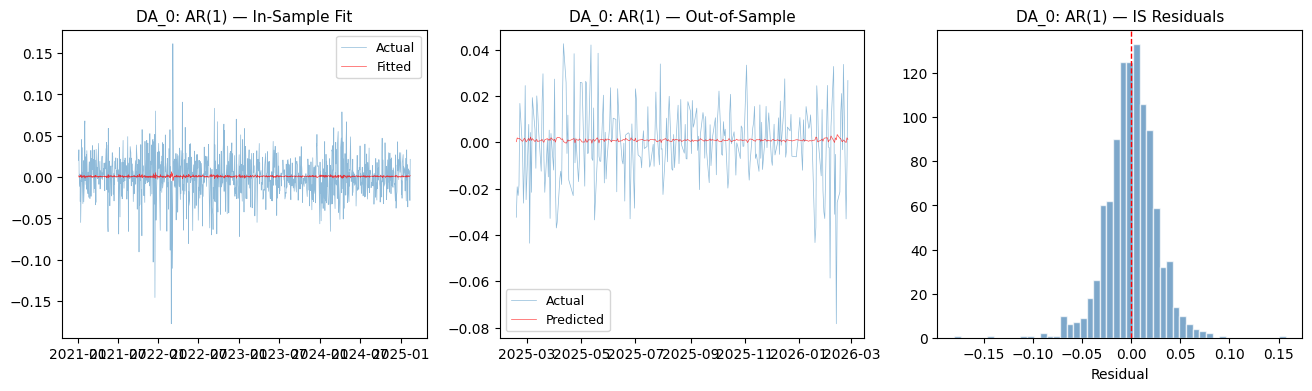

In [112]:
# Evaluate and visualise DA_0
results_da0 = evaluate_model(model_da0, train_da0, test_da0, target, features_da0, 'DA_0: AR(1)')
import statsmodels.api as sm
X_test = sm.add_constant(test_da0[features_da0])
pred_da0 = model_da0.predict(X_test)
plot_diagnostics(model_da0, train_da0, test_da0, target, features_da0, pred_da0, 'DA_0: AR(1)')

In [113]:
# DA_1: AR(1) + Energy Futures
features_da1 = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Brent', 'lag_r_Coal', 'lag_r_Power']
data_da1 = prepare_data(db, target, features_da1)
train_da1, test_da1 = train_test_split_ts(data_da1)
model_da1 = fit_ols(train_da1, target, features_da1)
print(model_da1.summary())

                            OLS Regression Results                            
Dep. Variable:                  r_EUA   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.372
Date:                Fri, 29 May 2026   Prob (F-statistic):           0.000606
Time:                        00:15:54   Log-Likelihood:                 2335.7
No. Observations:                1046   AIC:                            -4659.
Df Residuals:                    1040   BIC:                            -4630.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0009      0.001      1.165      


  DA_1: AR(1) + Energy
  Train: 1046 days | Test: 262 days
  IS R²:     0.0206
  Adj R²:    0.0159
  OOS RMSE:  0.01736
  OOS MAE:   0.01326
  Win Rate:  50.76%  (better than coin flip)


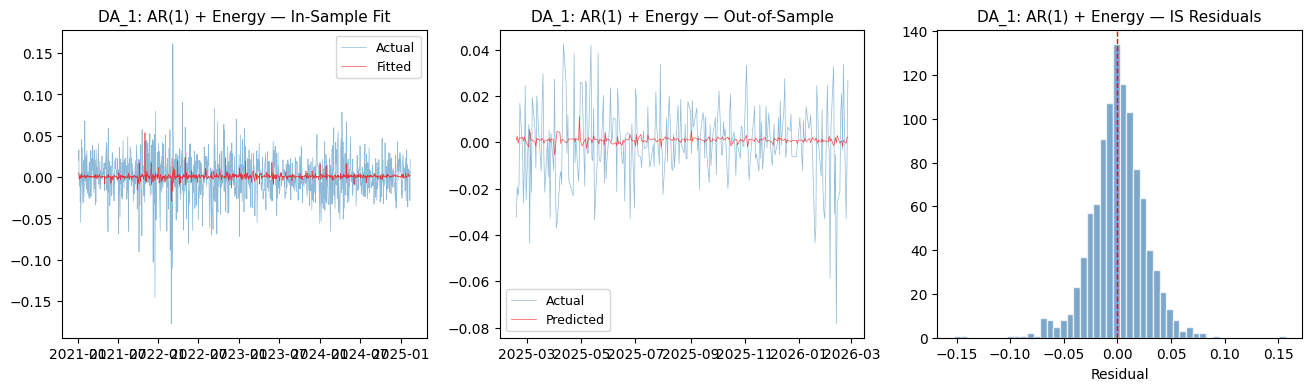

In [114]:
# Evaluate and visualise DA_1
results_da1 = evaluate_model(model_da1, train_da1, test_da1, target, features_da1, 'DA_1: AR(1) + Energy')
import statsmodels.api as sm
X_test = sm.add_constant(test_da1[features_da1])
pred_da1 = model_da1.predict(X_test)
plot_diagnostics(model_da1, train_da1, test_da1, target, features_da1, pred_da1, 'DA_1: AR(1) + Energy')

In [115]:
# F-test: DA_1 vs DA_0
    
data_common = prepare_data(db, target, features_da1)  # has all columns
train_common, test_common = train_test_split_ts(data_common)
  
# Fit restricted model (AR(1) only) on same data
model_restricted = fit_ols(train_common, target, ['lag_r_EUA'])
 
# Fit unrestricted model (AR(1) + energy) on same data
model_unrestricted = fit_ols(train_common, target, features_da1)
    
# Manual F-test
rss_r = model_restricted.ssr   # Residual sum of squares (restricted)
rss_u = model_unrestricted.ssr  # Residual sum of squares (unrestricted)
p = len(features_da1) - 1  # Number of additional features (4 energy variables)
n = len(train_common)
k = len(features_da1) + 1  # Total parameters in unrestricted model (including constant)
 
f_stat = ((rss_r - rss_u) / p) / (rss_u / (n - k))

from scipy import stats
f_pval = 1 - stats.f.cdf(f_stat, p, n - k)
   
print(f'F-test: DA_1 vs DA_0')
print(f'  F-statistic: {f_stat:.3f}')
print(f'  p-value: {f_pval:.4f}')
print(f'  Additional features tested: {p} (TTF, Brent, Coal, Power)')


F-test: DA_1 vs DA_0
  F-statistic: 5.211
  p-value: 0.0004
  Additional features tested: 4 (TTF, Brent, Coal, Power)


In [116]:
db = pd.read_csv('consolidated_db.csv', parse_dates=['trade_date'])
print(f'Loaded consolidated DB: {db.shape[0]} rows, {db.shape[1]} columns')
print(f'Date range: {db.trade_date.min().date()} to {db.trade_date.max().date()}')
print(f'\nColumns: {list(db.columns)}')

Loaded consolidated DB: 1310 rows, 22 columns
Date range: 2021-01-04 to 2026-02-25

Columns: ['trade_date', 'EUA_price', 'r_EUA', 'TTF', 'r_TTF', 'Coal', 'r_Coal', 'Brent', 'r_Brent', 'Power', 'r_Power', 'CDS', 'd_CDS', 'CSS', 'd_CSS', 'lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']


In [117]:
features_da2 = features_da1 + ['lag_d_CDS', 'lag_d_CSS']

data_da2 = prepare_data(db, target, features_da2)
train_da2, test_da2 = train_test_split_ts(data_da2)

print(f'Common sample: {len(data_da2)} obs  (train={len(train_da2)}, test={len(test_da2)})')
print(f'Date range: {data_da2.trade_date.min().date()} to {data_da2.trade_date.max().date()}')


model_da1 = fit_ols(train_da2, target, features_da1)
results_da1, pred_da1 = evaluate_model(model_da1, train_da2, test_da2, target, features_da1, 'DA_1: Energy Futures (common sample)')

Common sample: 1173 obs  (train=938, test=235)
Date range: 2021-01-06 to 2026-02-25

  DA_1: Energy Futures (common sample)
  Train: 938 days | Test: 235 days
  IS R²:     0.0226
  Adj R²:    0.0174
  OOS RMSE:  0.01721
  OOS MAE:   0.01305
  Win Rate:  48.94%  (no better than guessing)


In [118]:
# DA_2: clean dark & clean spark spreads
print('DA_2 features:', features_da2)

model_da2 = fit_ols(train_da2, target, features_da2)
results_da2, pred_da2 = evaluate_model(
    model_da2, train_da2, test_da2, target, features_da2,
    'DA_2: Energy + Spreads'
)
print(model_da2.summary())

DA_2 features: ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Brent', 'lag_r_Coal', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']

  DA_2: Energy + Spreads
  Train: 938 days | Test: 235 days
  IS R²:     0.0239
  Adj R²:    0.0166
  OOS RMSE:  0.01732
  OOS MAE:   0.01307
  Win Rate:  50.64%  (better than coin flip)
                            OLS Regression Results                            
Dep. Variable:                  r_EUA   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     3.254
Date:                Fri, 29 May 2026   Prob (F-statistic):            0.00203
Time:                        00:15:55   Log-Likelihood:                 2082.5
No. Observations:                 938   AIC:                            -4149.
Df Residuals:                     930   BIC:                            -4110.
Df Model:                           7                               

In [119]:
# F-test: DA_2 vs DA_1
# H0: coefficients on lag_d_CDS and lag_d_CSS are both zero
# H1: at least one is non-zero
print('F-test: Are the spread features (CDS + CSS) jointly significant?')
print('        Comparing DA_2 (unrestricted) vs DA_1 (restricted)\n')

f_stat, f_pval, df1, df2 = f_test_nested(model_da1, model_da2, len(train_da2))

F-test: Are the spread features (CDS + CSS) jointly significant?
        Comparing DA_2 (unrestricted) vs DA_1 (restricted)


  F-test: F(2.0, 930.0) = 0.5997,  p = 0.5492
  → Cannot reject H0: the extra features are NOT jointly significant.



  Residual diagnostics for DA_2:
    Durbin-Watson:  1.971  (OK — no strong autocorrelation)
    Breusch-Pagan:  stat=36.328, p=0.0000  (heteroscedastic — consider robust SE)


(np.float64(1.9710921197880742),
 np.float64(36.328097044361726),
 np.float64(6.285572114927168e-06))

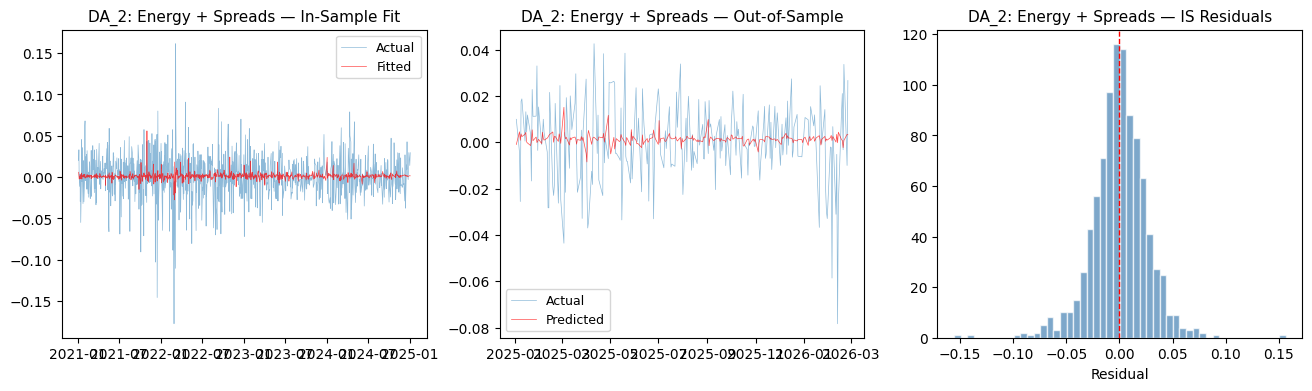

In [120]:
# Diagnostics for DA_2
plot_diagnostics(model_da2, train_da2, test_da2, target, features_da2, pred_da2, 'DA_2: Energy + Spreads')
residual_diagnostics(model_da2, 'DA_2')

In [121]:
# LOAD & ENGINEER EUA COT FEATURES

DATA_DIR = 'uploads/' 
cot_eua = pd.read_csv(DATA_DIR + 'cot_wide_format.csv', parse_dates=['Date'])
cot_eua = cot_eua.sort_values('Date').reset_index(drop=True)
print(f'EUA COT: {cot_eua.shape[0]} weekly observations')
print(f'Date range: {cot_eua.Date.min().date()} to {cot_eua.Date.max().date()}')

# NET positions (long_total - short_total) for each actor on ICE
# ICE has much better coverage than EEX for most actors
actors = ['IFCI', 'IF', 'OFI', 'CU', 'OWCO']

for actor in actors:
    long_col  = f'{actor}_Positions_ice_long_total'
    short_col = f'{actor}_Positions_ice_short_total'
    cot_eua[f'{actor}_net_ice'] = cot_eua[long_col] - cot_eua[short_col]

# Also compute EEX net positions where coverage is decent
# EEX has good coverage for IFCI, CU, OWCO
for actor in ['IFCI', 'CU', 'OWCO']:
    long_col  = f'{actor}_Positions_eex_long_total'
    short_col = f'{actor}_Positions_eex_short_total'
    cot_eua[f'{actor}_net_eex'] = cot_eua[long_col] - cot_eua[short_col]

# Derived features
# 1. Financial aggregate: IFCI + IF + OFI (all "financial" players combined)
cot_eua['Financial_net_ice'] = (cot_eua['IFCI_net_ice'] + 
                                 cot_eua['IF_net_ice'] + 
                                 cot_eua['OFI_net_ice'])

# 2. CU vs Financial ratio — compliance vs speculative positioning
#    Positive = compliance players more net long than financials
cot_eua['CU_vs_Financial'] = cot_eua['CU_net_ice'] - cot_eua['Financial_net_ice']

# First differences (weekly changes) — makes positions stationary
cot_features_eua = ['IFCI_net_ice', 'IF_net_ice', 'OFI_net_ice', 'CU_net_ice', 'OWCO_net_ice',
                     'IFCI_net_eex', 'CU_net_eex', 'OWCO_net_eex',
                     'Financial_net_ice', 'CU_vs_Financial']

for feat in cot_features_eua:
    cot_eua[f'd_{feat}'] = cot_eua[feat].diff()

print(f'\nEUA COT features engineered: {len(cot_features_eua)} net positions → {len(cot_features_eua)} first-diffs')
print('\nSample of net positions (last 5 weeks):')
cot_eua[['Date'] + [f'{a}_net_ice' for a in actors]].tail()

EUA COT: 271 weekly observations
Date range: 2021-01-08 to 2026-02-20

EUA COT features engineered: 10 net positions → 10 first-diffs

Sample of net positions (last 5 weeks):


,Date,IFCI_net_ice,IF_net_ice,OFI_net_ice,CU_net_ice,OWCO_net_ice
266,2026-01-23,-389855330.0,112519980.0,2368000.0,219668670.0,55565280.0
267,2026-01-30,-384250210.0,100616020.0,2148000.0,228685490.0,52837350.0
268,2026-02-06,-376608030.0,93998390.0,2248000.0,226246670.0,54410050.0
269,2026-02-13,-358718590.0,82409430.0,3015000.0,220074260.0,56414350.0
270,2026-02-20,-336639210.0,68826190.0,2598000.0,212349250.0,52902960.0


In [122]:
# LOAD & ENGINEER TTF COT FEATURES

cot_ttf = pd.read_csv(DATA_DIR + 'ttf_cot_wide_format.csv', parse_dates=['Date'])
cot_ttf = cot_ttf.sort_values('Date').reset_index(drop=True)
print(f'TTF COT: {cot_ttf.shape[0]} weekly observations')
print(f'Date range: {cot_ttf.Date.min().date()} to {cot_ttf.Date.max().date()}')
print('  (starts later than EUA COT — Nov 2022)')

# Net positions for TTF
for actor in actors:
    long_col  = f'{actor}_Positions_ttf_long_total'
    short_col = f'{actor}_Positions_ttf_short_total'
    cot_ttf[f'{actor}_net_ttf'] = cot_ttf[long_col] - cot_ttf[short_col]

# First differences
cot_features_ttf = [f'{a}_net_ttf' for a in actors]
for feat in cot_features_ttf:
    cot_ttf[f'd_{feat}'] = cot_ttf[feat].diff()

print(f'TTF COT features: {len(cot_features_ttf)} net positions → {len(cot_features_ttf)} first-diffs')

TTF COT: 172 weekly observations
Date range: 2022-11-11 to 2026-02-20
  (starts later than EUA COT — Nov 2022)
TTF COT features: 5 net positions → 5 first-diffs


In [123]:
# MERGE COT INTO DAILY DATABASE

db_cot = db[['trade_date', 'r_EUA', 'lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal',
              'lag_r_Brent', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']].copy()

# EUA COT: select first-diff columns + Date
eua_cot_cols = ['Date'] + [f'd_{feat}' for feat in cot_features_eua]
cot_eua_slim = cot_eua[eua_cot_cols].copy()
cot_eua_slim = cot_eua_slim.rename(columns={'Date': 'trade_date'})

# TTF COT: select first-diff columns + Date
ttf_cot_cols = ['Date'] + [f'd_{feat}' for feat in cot_features_ttf]
cot_ttf_slim = cot_ttf[ttf_cot_cols].copy()
cot_ttf_slim = cot_ttf_slim.rename(columns={'Date': 'trade_date'})

# Merge EUA COT (weekly) onto daily dates
# merge_asof: for each daily date, grab the MOST RECENT weekly COT report
db_cot = db_cot.sort_values('trade_date')
cot_eua_slim = cot_eua_slim.sort_values('trade_date')
cot_ttf_slim = cot_ttf_slim.sort_values('trade_date')

db_cot = pd.merge_asof(db_cot, cot_eua_slim, on='trade_date', direction='backward')
db_cot = pd.merge_asof(db_cot, cot_ttf_slim, on='trade_date', direction='backward')

# LAG all COT features by 1 day (day-ahead constraint)
all_cot_diff_cols = [f'd_{feat}' for feat in cot_features_eua] + [f'd_{feat}' for feat in cot_features_ttf]

for col in all_cot_diff_cols:
    db_cot[f'lag_{col}'] = db_cot[col].shift(1)

print(f'Daily DB with COT: {db_cot.shape[0]} rows, {db_cot.shape[1]} columns')
print(f'\nCOT coverage check (non-null counts for lagged COT features):')
lag_cot_cols = [f'lag_{c}' for c in all_cot_diff_cols]
print(db_cot[lag_cot_cols].notna().sum().to_string())

Daily DB with COT: 1310 rows, 39 columns

COT coverage check (non-null counts for lagged COT features):
lag_d_IFCI_net_ice         1192
lag_d_IF_net_ice           1192
lag_d_OFI_net_ice          1192
lag_d_CU_net_ice           1192
lag_d_OWCO_net_ice         1192
lag_d_IFCI_net_eex         1228
lag_d_CU_net_eex           1228
lag_d_OWCO_net_eex         1228
lag_d_Financial_net_ice    1192
lag_d_CU_vs_Financial      1192
lag_d_IFCI_net_ttf          827
lag_d_IF_net_ttf            827
lag_d_OFI_net_ttf           827
lag_d_CU_net_ttf            827
lag_d_OWCO_net_ttf          827


In [124]:
# SYSTEMATIC COT TESTING

target = 'r_EUA'
base_features = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power',
                  'lag_d_CDS', 'lag_d_CSS']

# Define COT feature groups to test
cot_test_configs = {
    # EUA COT: Individual ICE actors
    'COT_1: EUA IFCI (ICE)':       base_features + ['lag_d_IFCI_net_ice'],
    'COT_2: EUA IF (ICE)':         base_features + ['lag_d_IF_net_ice'],
    'COT_3: EUA OFI (ICE)':        base_features + ['lag_d_OFI_net_ice'],
    'COT_4: EUA CU (ICE)':         base_features + ['lag_d_CU_net_ice'],
    'COT_5: EUA OWCO (ICE)':       base_features + ['lag_d_OWCO_net_ice'],
    
    # EUA COT: Grouped
    'COT_6: EUA Financial agg':    base_features + ['lag_d_Financial_net_ice'],
    'COT_7: EUA CU vs Financial':  base_features + ['lag_d_CU_vs_Financial'],
    'COT_8: EUA All ICE actors':   base_features + [f'lag_d_{a}_net_ice' for a in actors],
    
    # EUA COT: EEX actors
    'COT_9: EUA IFCI+CU (EEX)':   base_features + ['lag_d_IFCI_net_eex', 'lag_d_CU_net_eex'],
    
    # TTF COT: Individual actors
    'COT_10: TTF IFCI':            base_features + ['lag_d_IFCI_net_ttf'],
    'COT_11: TTF IF':              base_features + ['lag_d_IF_net_ttf'],
    'COT_12: TTF CU':              base_features + ['lag_d_CU_net_ttf'],
    'COT_13: TTF All actors':      base_features + [f'lag_d_{a}_net_ttf' for a in actors],
    
    # Combined EUA + TTF COT
    'COT_14: EUA CU + TTF CU':    base_features + ['lag_d_CU_net_ice', 'lag_d_CU_net_ttf'],
    'COT_15: EUA Fin + TTF Fin':   base_features + ['lag_d_Financial_net_ice', 
                                                       'lag_d_IFCI_net_ttf', 'lag_d_IF_net_ttf'],
    
    # Kitchen sink
    'COT_16: All EUA+TTF COT':    base_features + [f'lag_d_{a}_net_ice' for a in actors] +
                                    ['lag_d_Financial_net_ice', 'lag_d_CU_vs_Financial'] +
                                    [f'lag_d_{a}_net_ttf' for a in actors],
}

print(f'Testing {len(cot_test_configs)} COT configurations on top of DA_2 baseline')
print(f'Base features ({len(base_features)}): {base_features}')

Testing 16 COT configurations on top of DA_2 baseline
Base features (7): ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']


In [125]:
# RUN ALL COT MODELS

all_results = []

# DA_2 baseline on the full COT-available sample
# DA_2 baseline (no COT) — use original data
data_base = prepare_data(db_cot, target, base_features)
train_base, test_base = train_test_split_ts(data_base)
model_base = fit_ols(train_base, target, base_features)
res_base, _ = evaluate_model(model_base, train_base, test_base, target, base_features,
                              'DA_2 Baseline (no COT)')
residual_diagnostics(model_base, 'DA_2 Baseline')
all_results.append(res_base)


print('  Testing COT configurations...')


for name, feats in cot_test_configs.items():
    try:
        data_i = prepare_data(db_cot, target, feats)
        if len(data_i) < 100:
            print(f'\n  SKIP {name}: only {len(data_i)} obs after dropping NaN')
            continue
        
        train_i, test_i = train_test_split_ts(data_i)
        model_i = fit_ols(train_i, target, feats)
        res_i, _ = evaluate_model(model_i, train_i, test_i, target, feats, name)
        all_results.append(res_i)
    except Exception as e:
        print(f'\n  ERROR on {name}: {e}')

print(f'\n\nCompleted: {len(all_results)} models (including baseline)')


  DA_2 Baseline (no COT)
  Train: 938 days | Test: 235 days
  IS R²:     0.0239
  Adj R²:    0.0166
  OOS RMSE:  0.01732
  OOS MAE:   0.01307
  Win Rate:  50.64%  (better than coin flip)

  Residual diagnostics for DA_2 Baseline:
    Durbin-Watson:  1.971  (OK — no strong autocorrelation)
    Breusch-Pagan:  stat=36.328, p=0.0000  (heteroscedastic — consider robust SE)
  Testing COT configurations...

  COT_1: EUA IFCI (ICE)
  Train: 845 days | Test: 212 days
  IS R²:     0.0271
  Adj R²:    0.0178
  OOS RMSE:  0.01765
  OOS MAE:   0.01325
  Win Rate:  54.25%  (better than coin flip)

  COT_2: EUA IF (ICE)
  Train: 845 days | Test: 212 days
  IS R²:     0.0275
  Adj R²:    0.0181
  OOS RMSE:  0.01772
  OOS MAE:   0.01327
  Win Rate:  50.47%  (better than coin flip)

  COT_3: EUA OFI (ICE)
  Train: 845 days | Test: 212 days
  IS R²:     0.0275
  Adj R²:    0.0182
  OOS RMSE:  0.01778
  OOS MAE:   0.01336
  Win Rate:  49.06%  (no better than guessing)

  COT_4: EUA CU (ICE)
  Train: 845

In [126]:
# COMPARISON TABLE — THE KEY OUTPUT

comparison = pd.DataFrame(all_results)
comparison = comparison.sort_values('Win_Rate', ascending=False)

# Format for display
display_cols = ['Model', 'n_train', 'n_test', 'IS_R2', 'Adj_R2', 'OOS_RMSE', 'Win_Rate']
comp_display = comparison[display_cols].copy()
comp_display['IS_R2'] = comp_display['IS_R2'].map('{:.4f}'.format)
comp_display['Adj_R2'] = comp_display['Adj_R2'].map('{:.4f}'.format)
comp_display['OOS_RMSE'] = comp_display['OOS_RMSE'].map('{:.5f}'.format)
comp_display['Win_Rate'] = comp_display['Win_Rate'].map('{:.2%}'.format)


print('  MODEL COMPARISON — Sorted by OOS Win Rate (descending)')
print(comp_display.to_string(index=False))
print('\n  NOTE: Models with TTF COT have fewer observations (starts Nov 2022).')

  MODEL COMPARISON — Sorted by OOS Win Rate (descending)
                     Model  n_train  n_test  IS_R2  Adj_R2 OOS_RMSE Win_Rate
     COT_5: EUA OWCO (ICE)      845     212 0.0271  0.0178  0.01766   54.72%
     COT_1: EUA IFCI (ICE)      845     212 0.0271  0.0178  0.01765   54.25%
  COT_6: EUA Financial agg      845     212 0.0270  0.0177  0.01766   53.77%
  COT_9: EUA IFCI+CU (EEX)      880     221 0.0299  0.0199  0.01765   53.39%
COT_7: EUA CU vs Financial      845     212 0.0269  0.0176  0.01766   52.83%
       COT_4: EUA CU (ICE)      845     212 0.0270  0.0177  0.01768   52.83%
    DA_2 Baseline (no COT)      938     235 0.0239  0.0166  0.01732   50.64%
       COT_2: EUA IF (ICE)      845     212 0.0275  0.0181  0.01772   50.47%
          COT_10: TTF IFCI      553     139 0.0136 -0.0009  0.01548   50.36%
   COT_16: All EUA+TTF COT      553     139 0.0341  0.0053  0.01552   50.36%
            COT_11: TTF IF      553     139 0.0198  0.0054  0.01546   49.64%
    COT_13: TTF All

In [127]:
# DEEP DIVE ON THE BEST MODEL

# Find the best COT model (exclude baseline)
cot_results = [r for r in all_results if r['Model'] != 'DA_2 Baseline (no COT)']
best = max(cot_results, key=lambda x: x['Win_Rate'])
best_name = best['Model']
best_features = cot_test_configs[best_name]

print(f'Best COT model: {best_name}')
print(f'Win Rate: {best["Win_Rate"]:.2%}')
print(f'Features: {best_features}')

# Re-fit for full diagnostics
data_best = prepare_data(db_cot, target, best_features)
train_best, test_best = train_test_split_ts(data_best)
model_best = fit_ols(train_best, target, best_features)
res_best, pred_best = evaluate_model(model_best, train_best, test_best, target, best_features, best_name)

print(model_best.summary())

Best COT model: COT_5: EUA OWCO (ICE)
Win Rate: 54.72%
Features: ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS', 'lag_d_OWCO_net_ice']

  COT_5: EUA OWCO (ICE)
  Train: 845 days | Test: 212 days
  IS R²:     0.0271
  Adj R²:    0.0178
  OOS RMSE:  0.01766
  OOS MAE:   0.01325
  Win Rate:  54.72%  (better than coin flip)
                            OLS Regression Results                            
Dep. Variable:                  r_EUA   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.914
Date:                Fri, 29 May 2026   Prob (F-statistic):            0.00326
Time:                        00:15:55   Log-Likelihood:                 1873.0
No. Observations:                 845   AIC:                            -3728.
Df Residuals:                     836   BIC:                            -368


  Residual diagnostics for COT_5: EUA OWCO (ICE):
    Durbin-Watson:  1.968  (OK — no strong autocorrelation)
    Breusch-Pagan:  stat=35.086, p=0.0000  (heteroscedastic — consider robust SE)


(np.float64(1.9675856085449572),
 np.float64(35.08619653858115),
 np.float64(2.5788887811691203e-05))

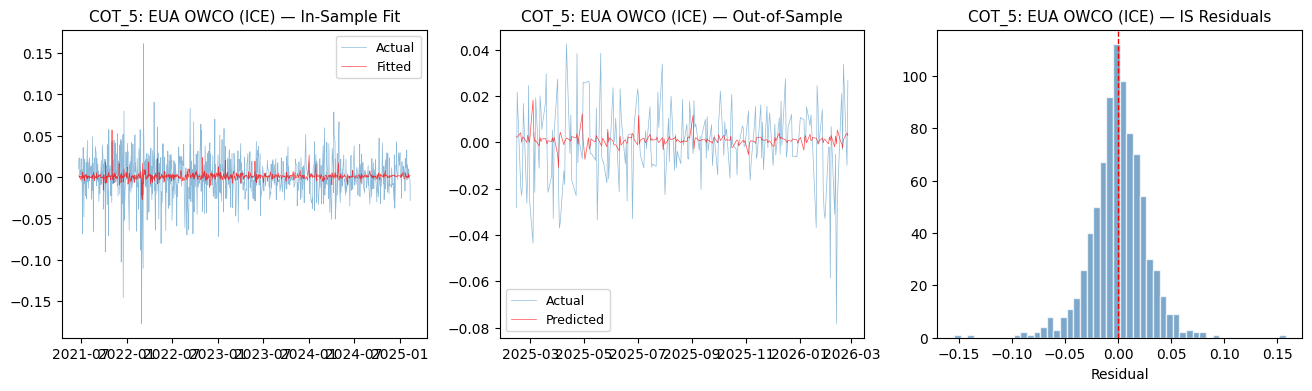

In [128]:
# Diagnostics for best COT model
plot_diagnostics(model_best, train_best, test_best, target, best_features, pred_best, best_name)
residual_diagnostics(model_best, best_name)

In [129]:
# F-test: Best COT model vs DA_2 baseline
# Need to fit both on the SAME sample
data_ftest = prepare_data(db_cot, target, best_features)  # dictated by best model's features
train_ft, test_ft = train_test_split_ts(data_ftest)

model_restricted_ft = fit_ols(train_ft, target, base_features)
model_unrestricted_ft = fit_ols(train_ft, target, best_features)

print(f'\nF-test: {best_name} vs DA_2 Baseline')
print(f'  Restricted:   {len(base_features)} features (DA_2)')
print(f'  Unrestricted: {len(best_features)} features (best COT)')
f_test_nested(model_restricted_ft, model_unrestricted_ft, len(train_ft))


F-test: COT_5: EUA OWCO (ICE) vs DA_2 Baseline
  Restricted:   7 features (DA_2)
  Unrestricted: 8 features (best COT)

  F-test: F(1.0, 836.0) = 0.1674,  p = 0.6825
  → Cannot reject H0: the extra features are NOT jointly significant.


(np.float64(0.16742659078341054), np.float64(0.6825138840770573), 1.0, 836.0)

In [130]:
# Correlation of all lagged COT features with r_EUA
lag_cot_cols = [c for c in db_cot.columns if c.startswith('lag_d_') and c != 'lag_d_CDS' and c != 'lag_d_CSS']
corr_data = db_cot[['r_EUA'] + lag_cot_cols].dropna()

corrs = corr_data.corr()['r_EUA'].drop('r_EUA').sort_values(key=abs, ascending=False)

print('Correlation of lagged COT features with r_EUA:')
print('  (sorted by absolute correlation)\n')
for feat, val in corrs.items():
    if pd.isna(val):
        print(f'  {feat:35s}   NaN (skipped)')
        continue

    bar = '█' * int(abs(val) * 200)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:35s}  {val:+.4f}  {sign}{bar}')


print(f'\nSample size: {len(corr_data)} days')

Correlation of lagged COT features with r_EUA:
  (sorted by absolute correlation)

  lag_d_OWCO_net_eex                   -0.0849  -████████████████
  lag_d_IF_net_ttf                     -0.0797  -███████████████
  lag_d_CU_net_ttf                     +0.0793  +███████████████
  lag_d_IFCI_net_eex                   +0.0716  +██████████████
  lag_d_OWCO_net_ice                   -0.0500  -█████████
  lag_d_CU_net_eex                     +0.0488  +█████████
  lag_d_OFI_net_ttf                    -0.0315  -██████
  lag_d_CU_net_ice                     +0.0247  +████
  lag_d_CU_vs_Financial                +0.0151  +███
  lag_d_IFCI_net_ttf                   -0.0100  -█
  lag_d_IFCI_net_ice                   -0.0087  -█
  lag_d_IF_net_ice                     +0.0068  +█
  lag_d_Financial_net_ice              -0.0066  -█
  lag_d_OFI_net_ice                    +0.0065  +█
  lag_d_OWCO_net_ttf                    NaN (skipped)

Sample size: 769 days


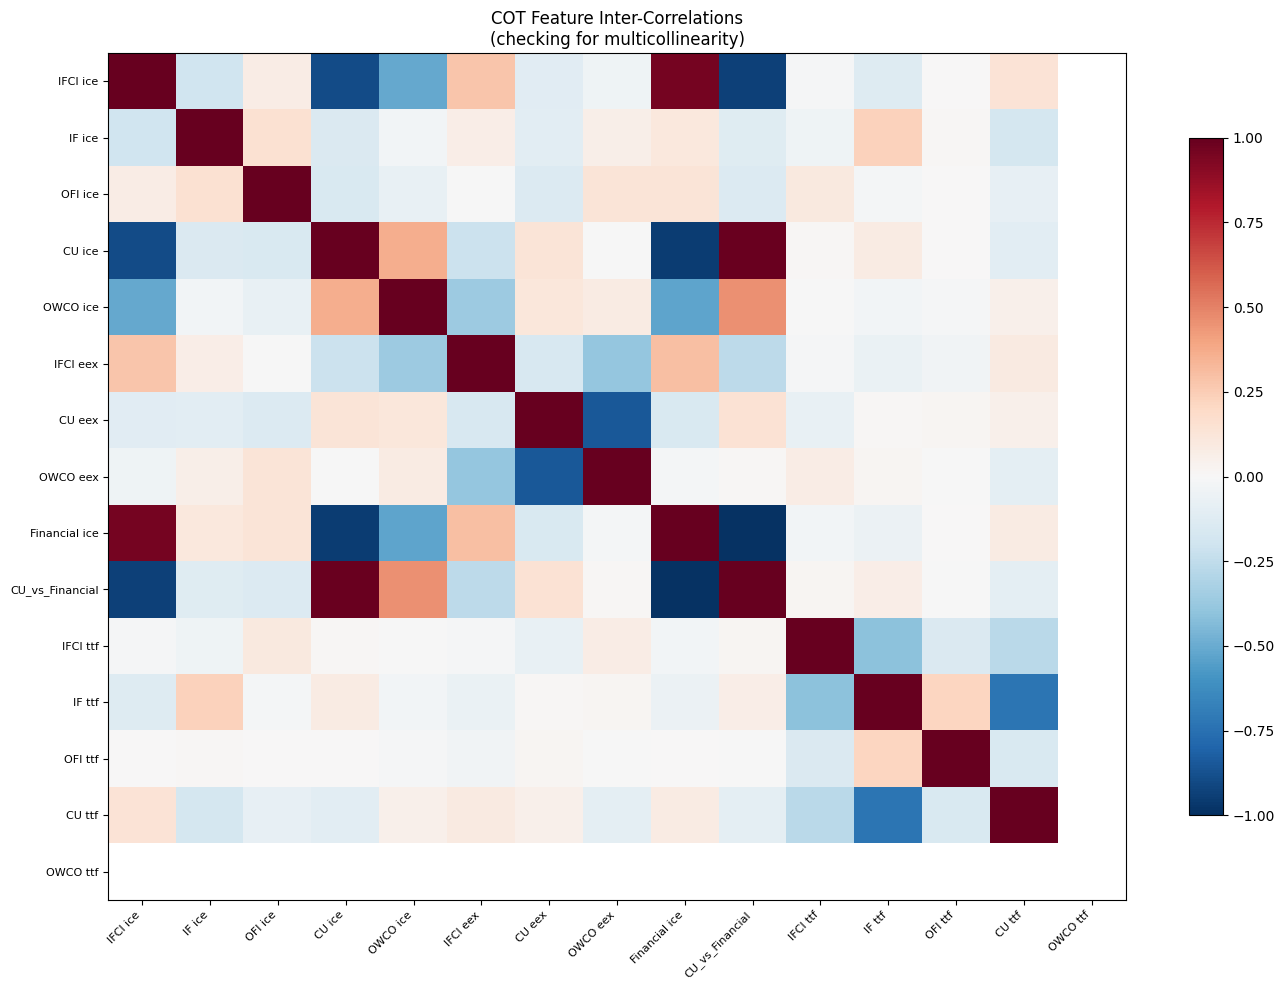


Highly correlated COT feature pairs (|r| > 0.7):
  lag_d_IFCI_net_ice <-> lag_d_CU_net_ice: -0.893
  lag_d_IFCI_net_ice <-> lag_d_Financial_net_ice: 0.953
  lag_d_IFCI_net_ice <-> lag_d_CU_vs_Financial: -0.937
  lag_d_CU_net_ice <-> lag_d_Financial_net_ice: -0.952
  lag_d_CU_net_ice <-> lag_d_CU_vs_Financial: 0.986
  lag_d_CU_net_eex <-> lag_d_OWCO_net_eex: -0.849
  lag_d_Financial_net_ice <-> lag_d_CU_vs_Financial: -0.990
  lag_d_IF_net_ttf <-> lag_d_CU_net_ttf: -0.729


In [131]:
# Heatmap of inter-correlations among COT features
# (checking for multicollinearity)
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 10))

cot_corr = corr_data[lag_cot_cols].corr()
im = ax.imshow(cot_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(lag_cot_cols)))
ax.set_yticks(range(len(lag_cot_cols)))
short_names = [c.replace('lag_d_', '').replace('_net_', ' ') for c in lag_cot_cols]
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
ax.set_title('COT Feature Inter-Correlations\n(checking for multicollinearity)', fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
print('\nHighly correlated COT feature pairs (|r| > 0.7):')
for i in range(len(lag_cot_cols)):
    for j in range(i+1, len(lag_cot_cols)):
        r = cot_corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {lag_cot_cols[i]} <-> {lag_cot_cols[j]}: {r:.3f}')

In [132]:
# Final comparison: progression from DA_0 through best COT

features_da0 = ['lag_r_EUA']
features_da1 = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power']

data_da0_full = prepare_data(db, target, features_da0)
train_da0f, test_da0f = train_test_split_ts(data_da0_full)
model_da0f = fit_ols(train_da0f, target, features_da0)
res_da0f, _ = evaluate_model(model_da0f, train_da0f, test_da0f, target, features_da0, 'DA_0: AR(1)')

data_da1_full = prepare_data(db, target, features_da1)
train_da1f, test_da1f = train_test_split_ts(data_da1_full)
model_da1f = fit_ols(train_da1f, target, features_da1)
res_da1f, _ = evaluate_model(model_da1f, train_da1f, test_da1f, target, features_da1, 'DA_1: Energy Futures')

# Combine all key results
final_progression = [res_da0f, res_da1f, results_da2, best]
final_df = pd.DataFrame(final_progression)[['Model', 'n_train', 'n_test', 'IS_R2', 'Adj_R2', 'OOS_RMSE', 'Win_Rate']]

final_df['IS_R2'] = final_df['IS_R2'].map('{:.4f}'.format)
final_df['Adj_R2'] = final_df['Adj_R2'].map('{:.4f}'.format)
final_df['OOS_RMSE'] = final_df['OOS_RMSE'].map('{:.5f}'.format)
final_df['Win_Rate'] = final_df['Win_Rate'].map('{:.2%}'.format)

print('\n' + final_df.to_string(index=False))




  DA_0: AR(1)
  Train: 1046 days | Test: 262 days
  IS R²:     0.0010
  Adj R²:    0.0000
  OOS RMSE:  0.01721
  OOS MAE:   0.01315
  Win Rate:  49.24%  (no better than guessing)

  DA_1: Energy Futures
  Train: 1046 days | Test: 262 days
  IS R²:     0.0206
  Adj R²:    0.0159
  OOS RMSE:  0.01736
  OOS MAE:   0.01326
  Win Rate:  50.76%  (better than coin flip)

                 Model  n_train  n_test  IS_R2 Adj_R2 OOS_RMSE Win_Rate
           DA_0: AR(1)     1046     262 0.0010 0.0000  0.01721   49.24%
  DA_1: Energy Futures     1046     262 0.0206 0.0159  0.01736   50.76%
DA_2: Energy + Spreads      938     235 0.0239 0.0166  0.01732   50.64%
 COT_5: EUA OWCO (ICE)      845     212 0.0271 0.0178  0.01766   54.72%


In [133]:

DATA_DIR = 'uploads/'
# Load auction data
auctions = pd.read_csv(DATA_DIR + 'eu_auctions_combined.csv', parse_dates=['date'])
auctions = auctions.sort_values('date').reset_index(drop=True)
print(f'Auctions: {auctions.shape[0]} records')
print(f'Date range: {auctions.date.min().date()} to {auctions.date.max().date()}')
print(f'Auction types: {auctions.auction_type.value_counts().to_dict()}')

# Load EUA prices for computing auction premium
eua = pd.read_csv(DATA_DIR + 'eua_front_year.csv', parse_dates=['trade_date'])
eua = eua.sort_values('trade_date').reset_index(drop=True)

# Compute prior-day settlement for auction premium
eua['prior_settlement'] = eua['settlement'].shift(1)

# Merge auction data with EUA settlement
auctions = auctions.merge(
    eua[['trade_date', 'settlement', 'prior_settlement', 'volume', 'open_interest']],
    left_on='date', right_on='trade_date', how='left'
)

# Feature 1: Auction Premium
# clearing_price - prior_day_settlement
# Positive = strong demand (buyers pay more at auction than secondary market)
# Negative = weak demand (auction clears below secondary market)
auctions['auction_premium'] = auctions['clearing_price'] - auctions['prior_settlement']

# Feature 2: Vol/OI ratio
# Futures trading volume / open interest on auction day
# High Vol/OI = more active trading around auction (information event)
auctions['vol_oi'] = auctions['volume'] / auctions['open_interest']

# Feature 3: Bid intensity
# Number of bids normalised by number of bidders
auctions['bid_intensity'] = auctions['bids'] / auctions['bidders']

print(f'\nAuction premium stats:')
print(f'  Mean: {auctions.auction_premium.mean():.3f} EUR/t')
print(f'  Median: {auctions.auction_premium.median():.3f} EUR/t')
print(f'  Std: {auctions.auction_premium.std():.3f}')
print(f'\nCover ratio stats: mean={auctions.cover_ratio.mean():.2f}, median={auctions.cover_ratio.median():.2f}')
print(f'Vol/OI stats: mean={auctions.vol_oi.mean():.4f}, median={auctions.vol_oi.median():.4f}')

Auctions: 1124 records
Date range: 2021-01-29 to 2026-02-24
Auction types: {'EU': 743, 'Germany': 241, 'Poland': 140}

Auction premium stats:
  Mean: -1.140 EUR/t
  Median: -0.830 EUR/t
  Std: 3.600

Cover ratio stats: mean=1.85, median=1.73
Vol/OI stats: mean=0.0809, median=0.0736


In [134]:
# Some days have multiple auctions (EU + Germany on same day).
# We aggregate: mean premium, max cover ratio, total volume offered.

daily_auction = auctions.groupby('date').agg(
    auction_premium_mean = ('auction_premium', 'mean'),
    auction_premium_max  = ('auction_premium', 'max'),
    cover_ratio_mean     = ('cover_ratio', 'mean'),
    cover_ratio_max      = ('cover_ratio', 'max'),
    vol_offered_total    = ('vol_offered', 'sum'),
    bidders_mean         = ('bidders', 'mean'),
    bid_intensity_mean   = ('bid_intensity', 'mean'),
    n_auctions           = ('clearing_price', 'count'),
    vol_oi               = ('vol_oi', 'first'),  # same for all auctions on a day
).reset_index()

daily_auction = daily_auction.rename(columns={'date': 'trade_date'})
print(f'Daily auction features: {daily_auction.shape[0]} unique auction days')


# NOT every day has an auction. Non-auction days get NaN.
# Strategy: forward-fill the most recent auction info to non-auction days
# Then lag by 1 for day-ahead constraint.

db_full = db.copy()
db_full = db_full.merge(daily_auction, on='trade_date', how='left')

# Create "has_auction" indicator
db_full['has_auction'] = db_full['auction_premium_mean'].notna().astype(int)

# Forward-fill auction features to non-auction days
auction_cols = ['auction_premium_mean', 'cover_ratio_mean', 'vol_oi', 
                'bidders_mean', 'bid_intensity_mean']
for col in auction_cols:
    db_full[col] = db_full[col].ffill()

# Lag all auction features by 1 day (day-ahead constraint)
for col in auction_cols + ['has_auction']:
    db_full[f'lag_{col}'] = db_full[col].shift(1)

print(f'\nMerged DB: {db_full.shape[0]} rows, {db_full.shape[1]} columns')
print(f'Non-null lagged auction premium: {db_full["lag_auction_premium_mean"].notna().sum()}')

Daily auction features: 1118 unique auction days

Merged DB: 1310 rows, 38 columns
Non-null lagged auction premium: 1290


Stationarity checks for auction features:


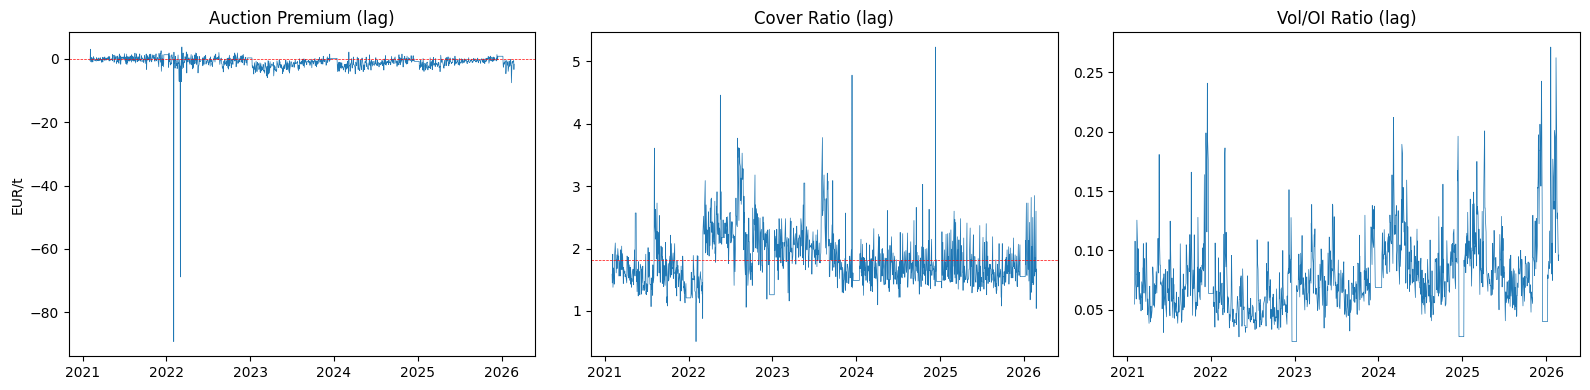

In [135]:
# Stationarity check on auction features
print('Stationarity checks for auction features:')
adf_test(db_full['lag_auction_premium_mean'], 'lag_auction_premium')
adf_test(db_full['lag_cover_ratio_mean'], 'lag_cover_ratio')
adf_test(db_full['lag_vol_oi'], 'lag_vol_oi')
adf_test(db_full['lag_bidders_mean'], 'lag_bidders')

# Visualise auction premium over time
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(db_full['trade_date'], db_full['lag_auction_premium_mean'], lw=0.5)
axes[0].axhline(0, color='red', ls='--', lw=0.5)
axes[0].set_title('Auction Premium (lag)')
axes[0].set_ylabel('EUR/t')

axes[1].plot(db_full['trade_date'], db_full['lag_cover_ratio_mean'], lw=0.5)
axes[1].axhline(db_full['lag_cover_ratio_mean'].mean(), color='red', ls='--', lw=0.5)
axes[1].set_title('Cover Ratio (lag)')

axes[2].plot(db_full['trade_date'], db_full['lag_vol_oi'], lw=0.5)
axes[2].set_title('Vol/OI Ratio (lag)')

plt.tight_layout()
plt.show()

In [136]:
target = 'r_EUA'
base_features = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power',
                  'lag_d_CDS', 'lag_d_CSS']

auction_configs = {
    'AUC_1: Premium only':         base_features + ['lag_auction_premium_mean'],
    'AUC_2: Cover ratio only':     base_features + ['lag_cover_ratio_mean'],
    'AUC_3: Vol/OI only':          base_features + ['lag_vol_oi'],
    'AUC_4: Has_auction indicator': base_features + ['lag_has_auction'],
    'AUC_5: Premium + Cover':      base_features + ['lag_auction_premium_mean', 'lag_cover_ratio_mean'],
    'AUC_6: Premium + Vol/OI':     base_features + ['lag_auction_premium_mean', 'lag_vol_oi'],
    'AUC_7: All auction signals':  base_features + ['lag_auction_premium_mean', 'lag_cover_ratio_mean',
                                                     'lag_vol_oi', 'lag_bidders_mean'],
}

all_results = []

# Baseline on auction-available sample
data_base = prepare_data(db_full, target, base_features)
train_base, test_base = train_test_split_ts(data_base)
model_base = fit_ols(train_base, target, base_features)
res_base, _ = evaluate_model(model_base, train_base, test_base, target, base_features, 'DA_2 Baseline (auction sample)')
all_results.append(res_base)

print()
for name, feats in auction_configs.items():
    try:
        data_i = prepare_data(db_full, target, feats)
        if len(data_i) < 100:
            print(f'  SKIP {name}: only {len(data_i)} obs')
            continue
        train_i, test_i = train_test_split_ts(data_i)
        model_i = fit_ols(train_i, target, feats)
        res_i, _ = evaluate_model(model_i, train_i, test_i, target, feats, name)
        all_results.append(res_i)
    except Exception as e:
        print(f'  ERROR {name}: {e}')

print(f'\nCompleted: {len(all_results)} auction models')


  DA_2 Baseline (auction sample)
  Train: 938 days | Test: 235 days
  IS R²:     0.0239
  Adj R²:    0.0166
  OOS RMSE:  0.01732
  OOS MAE:   0.01307
  Win Rate:  50.64%  (better than coin flip)


  AUC_1: Premium only
  Train: 924 days | Test: 231 days
  IS R²:     0.0251
  Adj R²:    0.0166
  OOS RMSE:  0.01740
  OOS MAE:   0.01307
  Win Rate:  50.22%  (better than coin flip)

  AUC_2: Cover ratio only
  Train: 924 days | Test: 231 days
  IS R²:     0.0233
  Adj R²:    0.0148
  OOS RMSE:  0.01733
  OOS MAE:   0.01305
  Win Rate:  51.95%  (better than coin flip)

  AUC_3: Vol/OI only
  Train: 924 days | Test: 231 days
  IS R²:     0.0249
  Adj R²:    0.0164
  OOS RMSE:  0.01730
  OOS MAE:   0.01311
  Win Rate:  51.08%  (better than coin flip)

  AUC_4: Has_auction indicator
  Train: 938 days | Test: 235 days
  IS R²:     0.0270
  Adj R²:    0.0186
  OOS RMSE:  0.01716
  OOS MAE:   0.01294
  Win Rate:  53.62%  (better than coin flip)

  AUC_5: Premium + Cover
  Train: 924 days | Test:

In [137]:
# Auction comparison table
auc_comp = pd.DataFrame(all_results)
auc_comp = auc_comp.sort_values('Win_Rate', ascending=False)
display_cols = ['Model', 'n_train', 'n_test', 'IS_R2', 'Adj_R2', 'Win_Rate']
comp_d = auc_comp[display_cols].copy()
comp_d['IS_R2'] = comp_d['IS_R2'].map('{:.4f}'.format)
comp_d['Adj_R2'] = comp_d['Adj_R2'].map('{:.4f}'.format)
comp_d['Win_Rate'] = comp_d['Win_Rate'].map('{:.2%}'.format)
print('\n' + '=' * 85)
print('  AUCTION MODEL COMPARISON — Sorted by Win Rate')
print('=' * 85)
print(comp_d.to_string(index=False))

# ── Best auction model details ──
auc_only = [r for r in all_results if r['Model'] != 'DA_2 Baseline (auction sample)']
if auc_only:
    best_auc = max(auc_only, key=lambda x: x['Win_Rate'])
    best_name = best_auc['Model']
    best_feats = auction_configs[best_name]
    
    print(f'\nBest auction model: {best_name} (WR={best_auc["Win_Rate"]:.2%})')
    
    # Refit for full summary
    data_b = prepare_data(db_full, target, best_feats)
    tr_b, te_b = train_test_split_ts(data_b)
    model_b = fit_ols(tr_b, target, best_feats)
    
    # F-test vs baseline
    model_r = fit_ols(tr_b, target, base_features)
    print(f'\nF-test: {best_name} vs DA_2 baseline')
    f_test_nested(model_r, model_b, len(tr_b))
    
    print('\n── Regression Summary ──')
    print(model_b.summary())


  AUCTION MODEL COMPARISON — Sorted by Win Rate
                         Model  n_train  n_test  IS_R2 Adj_R2 Win_Rate
  AUC_4: Has_auction indicator      938     235 0.0270 0.0186   53.62%
       AUC_2: Cover ratio only      924     231 0.0233 0.0148   51.95%
        AUC_5: Premium + Cover      924     231 0.0253 0.0157   51.95%
            AUC_3: Vol/OI only      924     231 0.0249 0.0164   51.08%
DA_2 Baseline (auction sample)      938     235 0.0239 0.0166   50.64%
           AUC_1: Premium only      924     231 0.0251 0.0166   50.22%
       AUC_6: Premium + Vol/OI      924     231 0.0271 0.0175   49.78%
    AUC_7: All auction signals      924     231 0.0321 0.0204   48.92%

Best auction model: AUC_4: Has_auction indicator (WR=53.62%)

F-test: AUC_4: Has_auction indicator vs DA_2 baseline

  F-test: F(1.0, 929.0) = 2.9663,  p = 0.0854
  → Cannot reject H0: the extra features are NOT jointly significant.

── Regression Summary ──
                            OLS Regression Results  

In [138]:
opts = pd.read_csv(DATA_DIR + 'opt_new_features.csv', parse_dates=['date'])
opts = opts.sort_values('date').reset_index(drop=True)
print(f'Options features: {opts.shape[0]} rows, {opts.shape[1]} columns')
print(f'Date range: {opts.date.min().date()} to {opts.date.max().date()}')

# Separate column types
raw_cols = [c for c in opts.columns if not c.startswith('d_') and not c.startswith('z26_') and c != 'date']
diff_cols = [c for c in opts.columns if c.startswith('d_')]
z_cols = [c for c in opts.columns if c.startswith('z26_')]

print(f'\nRaw level features ({len(raw_cols)}): {raw_cols}')
print(f'First-diff features ({len(diff_cols)}): {diff_cols}')
print(f'Z-score features ({len(z_cols)}): {z_cols}')

# Coverage check
print(f'\nCoverage (non-null %):')
for c in raw_cols:
    pct = opts[c].notna().mean() * 100
    if pct < 100:
        print(f'  {c}: {pct:.0f}%')
print('  All other raw features: 100%')

Options features: 1221 rows, 46 columns
Date range: 2021-06-07 to 2026-02-25

Raw level features (16): ['pc_oi', 'pc_vol', 'dec_pc_oi', 'total_oi', 'oi_wt_iv', 'oi_skew', 'dec_total_oi', 'dec_oi_share', 'near_dec_ratio', 'total_opt_vol', 'dec_call_share', 'dec_put_share', 'dec_iv_calls', 'dec_iv_puts', 'dec_iv_skew', 'vol_spike']
First-diff features (15): ['d_pc_oi', 'd_pc_vol', 'd_dec_pc_oi', 'd_total_oi', 'd_oi_wt_iv', 'd_oi_skew', 'd_dec_total_oi', 'd_dec_oi_share', 'd_near_dec_ratio', 'd_dec_call_share', 'd_dec_put_share', 'd_dec_iv_calls', 'd_dec_iv_puts', 'd_dec_iv_skew', 'd_vol_spike']
Z-score features (14): ['z26_pc_oi', 'z26_pc_vol', 'z26_dec_pc_oi', 'z26_total_oi', 'z26_oi_wt_iv', 'z26_oi_skew', 'z26_dec_total_oi', 'z26_dec_oi_share', 'z26_near_dec_ratio', 'z26_dec_call_share', 'z26_dec_put_share', 'z26_dec_iv_calls', 'z26_dec_iv_puts', 'z26_dec_iv_skew']

Coverage (non-null %):
  pc_vol: 97%
  oi_skew: 77%
  vol_spike: 100%
  All other raw features: 100%


In [139]:
# Rename date column for merge
opts_slim = opts.rename(columns={'date': 'trade_date'})

# Merge onto the daily database (left join — options start later)
db_opts = db_full.merge(opts_slim, on='trade_date', how='left')

# The first-diffs (d_) and z-scores (z26_) are already daily changes,
# but we still need to lag them for the day-ahead constraint.
opt_feature_cols = diff_cols + z_cols
for col in opt_feature_cols:
    db_opts[f'lag_{col}'] = db_opts[col].shift(1)

# Also lag a few key raw levels that might carry signal as levels
level_feats_to_lag = ['dec_iv_skew', 'pc_oi', 'dec_pc_oi', 'oi_wt_iv', 'vol_spike']
for col in level_feats_to_lag:
    db_opts[f'lag_{col}'] = db_opts[col].shift(1)

print(f'Merged DB with options: {db_opts.shape[0]} rows, {db_opts.shape[1]} columns')
print(f'Non-null lag_d_total_oi: {db_opts["lag_d_total_oi"].notna().sum()}')
print(f'Non-null lag_z26_oi_skew: {db_opts["lag_z26_oi_skew"].notna().sum()}')

Merged DB with options: 1310 rows, 117 columns
Non-null lag_d_total_oi: 1199
Non-null lag_z26_oi_skew: 491


In [140]:
# Stationarity checks on key options features
print('Stationarity checks for options features:')
for col in ['lag_d_total_oi', 'lag_d_pc_oi', 'lag_d_dec_iv_skew', 'lag_d_oi_wt_iv',
            'lag_z26_pc_oi', 'lag_z26_oi_skew', 'lag_z26_dec_iv_skew',
            'lag_dec_iv_skew', 'lag_pc_oi']:
    if col in db_opts.columns:
        adf_test(db_opts[col], col)

Stationarity checks for options features:


In [141]:
# All lagged options features
lag_opt_cols = [c for c in db_opts.columns if c.startswith('lag_d_') or c.startswith('lag_z26_') or c.startswith('lag_dec_iv') or c.startswith('lag_pc_') or c.startswith('lag_oi_')]
# Exclude the spread/COT/auction lags already in db
lag_opt_cols = [c for c in lag_opt_cols if c not in ['lag_d_CDS', 'lag_d_CSS']]

corr_data = db_opts[['r_EUA'] + lag_opt_cols].dropna()
corrs = corr_data.corr()['r_EUA'].drop('r_EUA').sort_values(key=abs, ascending=False)

print(f'Options feature correlations with r_EUA (n={len(corr_data)}):')
print(f'(sorted by |correlation|)\n')
for feat, val in corrs.head(20).items():
    bar = '█' * int(abs(val) * 150)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:35s}  {val:+.4f}  {sign}{bar}')

# Also load the reference feature search for comparison
try:
    feat_search = pd.read_csv(DATA_DIR + 'da_options_feature_search.csv')
    print(f'\n── Reference feature search (top features by partial R²) ──')
    top_ref = feat_search.sort_values('part_r2', ascending=False).head(10)
    print(top_ref[['feature', 'n', 'biv_p', 'biv_r2', 'part_r2', 'pcorr']].to_string(index=False))
except:
    print('  (reference file not available)')

Options feature correlations with r_EUA (n=348):
(sorted by |correlation|)

  lag_d_dec_total_oi                   +0.2553  +██████████████████████████████████████
  lag_d_total_oi                       +0.2436  +████████████████████████████████████
  lag_d_dec_call_share                 +0.1795  +██████████████████████████
  lag_d_dec_oi_share                   +0.1567  +███████████████████████
  lag_d_pc_oi                          +0.1410  +█████████████████████
  lag_d_dec_iv_calls                   -0.1385  -████████████████████
  lag_d_dec_put_share                  +0.1217  +██████████████████
  lag_d_oi_wt_iv                       -0.1167  -█████████████████
  lag_z26_total_oi                     +0.1142  +█████████████████
  lag_d_near_dec_ratio                 -0.1094  -████████████████
  lag_z26_oi_skew                      -0.1042  -███████████████
  lag_d_dec_iv_puts                    -0.1002  -███████████████
  lag_z26_dec_total_oi                 +0.0985  +█████████████

In [142]:
target = 'r_EUA'
base_features = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power',
                  'lag_d_CDS', 'lag_d_CSS']

opt_configs = {
    # OI-based features
    'OPT_1: d_total_oi':           base_features + ['lag_d_total_oi'],
    'OPT_2: d_dec_total_oi':       base_features + ['lag_d_dec_total_oi'],
    'OPT_3: d_pc_oi':              base_features + ['lag_d_pc_oi'],
    
    # IV-based features
    'OPT_4: d_oi_wt_iv':           base_features + ['lag_d_oi_wt_iv'],
    'OPT_5: d_dec_iv_calls':       base_features + ['lag_d_dec_iv_calls'],
    'OPT_6: d_dec_iv_puts':        base_features + ['lag_d_dec_iv_puts'],
    'OPT_7: d_dec_iv_skew':        base_features + ['lag_d_dec_iv_skew'],
    
    # Z-score features (regime-relative)
    'OPT_8: z26_oi_skew':          base_features + ['lag_z26_oi_skew'],
    'OPT_9: z26_pc_oi':            base_features + ['lag_z26_pc_oi'],
    'OPT_10: z26_dec_iv_skew':     base_features + ['lag_z26_dec_iv_skew'],
    'OPT_11: z26_oi_wt_iv':        base_features + ['lag_z26_oi_wt_iv'],
    
    # Level features
    'OPT_12: dec_iv_skew level':   base_features + ['lag_dec_iv_skew'],
    'OPT_13: pc_oi level':         base_features + ['lag_pc_oi'],
    
    # Volume-based
    'OPT_14: d_vol_spike':         base_features + ['lag_d_vol_spike'],
    
    # Combined: top OI + IV features
    'OPT_15: OI + IV combo':       base_features + ['lag_d_total_oi', 'lag_d_dec_iv_skew'],
    'OPT_16: OI + PC ratio':       base_features + ['lag_d_total_oi', 'lag_d_pc_oi'],
    'OPT_17: Top 3 (OI+PC+skew)':  base_features + ['lag_d_total_oi', 'lag_d_pc_oi', 'lag_d_dec_iv_skew'],
    'OPT_18: Z-score combo':       base_features + ['lag_z26_oi_skew', 'lag_z26_pc_oi', 'lag_z26_dec_iv_skew'],
}

opt_results = []

# Baseline on options-available sample
data_base_o = prepare_data(db_opts, target, base_features)
train_bo, test_bo = train_test_split_ts(data_base_o)
model_bo = fit_ols(train_bo, target, base_features)
res_bo, _ = evaluate_model(model_bo, train_bo, test_bo, target, base_features, 'DA_2 Baseline (options sample)')
opt_results.append(res_bo)

print()
for name, feats in opt_configs.items():
    try:
        data_i = prepare_data(db_opts, target, feats)
        if len(data_i) < 100:
            print(f'  SKIP {name}: only {len(data_i)} obs')
            continue
        train_i, test_i = train_test_split_ts(data_i)
        model_i = fit_ols(train_i, target, feats)
        res_i, _ = evaluate_model(model_i, train_i, test_i, target, feats, name)
        opt_results.append(res_i)
    except Exception as e:
        print(f'  ERROR {name}: {e}')

print(f'\nCompleted: {len(opt_results)} options models')


  DA_2 Baseline (options sample)
  Train: 938 days | Test: 235 days
  IS R²:     0.0239
  Adj R²:    0.0166
  OOS RMSE:  0.01732
  OOS MAE:   0.01307
  Win Rate:  50.64%  (better than coin flip)


  OPT_1: d_total_oi
  Train: 851 days | Test: 213 days
  IS R²:     0.0540
  Adj R²:    0.0450
  OOS RMSE:  0.01821
  OOS MAE:   0.01377
  Win Rate:  48.83%  (no better than guessing)

  OPT_2: d_dec_total_oi
  Train: 851 days | Test: 213 days
  IS R²:     0.0563
  Adj R²:    0.0473
  OOS RMSE:  0.01815
  OOS MAE:   0.01355
  Win Rate:  52.58%  (better than coin flip)

  OPT_3: d_pc_oi
  Train: 851 days | Test: 213 days
  IS R²:     0.0345
  Adj R²:    0.0254
  OOS RMSE:  0.01779
  OOS MAE:   0.01353
  Win Rate:  46.95%  (no better than guessing)

  OPT_4: d_oi_wt_iv
  Train: 851 days | Test: 213 days
  IS R²:     0.0274
  Adj R²:    0.0182
  OOS RMSE:  0.01778
  OOS MAE:   0.01342
  Win Rate:  48.83%  (no better than guessing)

  OPT_5: d_dec_iv_calls
  Train: 851 days | Test: 213 days
  IS

In [143]:
# Options comparison table
opt_comp = pd.DataFrame(opt_results)
opt_comp = opt_comp.sort_values('Win_Rate', ascending=False)
display_cols = ['Model', 'n_train', 'n_test', 'IS_R2', 'Adj_R2', 'Win_Rate']
comp_o = opt_comp[display_cols].copy()
comp_o['IS_R2'] = comp_o['IS_R2'].map('{:.4f}'.format)
comp_o['Adj_R2'] = comp_o['Adj_R2'].map('{:.4f}'.format)
comp_o['Win_Rate'] = comp_o['Win_Rate'].map('{:.2%}'.format)
print('\n' + '=' * 85)
print('  OPTIONS MODEL COMPARISON — Sorted by Win Rate')
print('=' * 85)
print(comp_o.to_string(index=False))

# Best options model
opt_only = [r for r in opt_results if 'Baseline' not in r['Model']]
if opt_only:
    best_opt = max(opt_only, key=lambda x: x['Win_Rate'])
    best_oname = best_opt['Model']
    best_ofeats = opt_configs[best_oname]
    print(f'\nBest options model: {best_oname} (WR={best_opt["Win_Rate"]:.2%})')
    
    data_bo2 = prepare_data(db_opts, target, best_ofeats)
    tr_bo2, te_bo2 = train_test_split_ts(data_bo2)
    model_bo2 = fit_ols(tr_bo2, target, best_ofeats)
    model_br2 = fit_ols(tr_bo2, target, base_features)
    
    print(f'\nF-test: {best_oname} vs DA_2 baseline')
    f_test_nested(model_br2, model_bo2, len(tr_bo2))
    
    print('\n── Regression Summary ──')
    print(model_bo2.summary())


  OPTIONS MODEL COMPARISON — Sorted by Win Rate
                         Model  n_train  n_test  IS_R2 Adj_R2 Win_Rate
            OPT_8: z26_oi_skew      352      88 0.0615 0.0396   54.55%
       OPT_10: z26_dec_iv_skew      832     208 0.0283 0.0189   54.33%
          OPT_11: z26_oi_wt_iv      832     208 0.0292 0.0198   53.37%
         OPT_2: d_dec_total_oi      851     213 0.0563 0.0473   52.58%
              OPT_9: z26_pc_oi      832     208 0.0271 0.0177   52.40%
         OPT_5: d_dec_iv_calls      851     213 0.0279 0.0186   52.11%
          OPT_6: d_dec_iv_puts      851     213 0.0274 0.0181   50.70%
          OPT_7: d_dec_iv_skew      851     213 0.0268 0.0175   50.70%
DA_2 Baseline (options sample)      938     235 0.0239 0.0166   50.64%
           OPT_14: d_vol_spike      848     212 0.0274 0.0181   50.47%
         OPT_16: OI + PC ratio      851     213 0.0541 0.0440   50.23%
         OPT_18: Z-score combo      352      88 0.0648 0.0374   50.00%
    OPT_17: Top 3 (OI+PC+ske

In [144]:
# Identify best single feature from each family based on our tests above

combo_configs = {
    'COMBO_1: DA_2 + best auction':       base_features + ['lag_auction_premium_mean'],
    'COMBO_2: DA_2 + OI change':          base_features + ['lag_d_total_oi'],
    'COMBO_3: DA_2 + auction + OI':       base_features + ['lag_auction_premium_mean', 'lag_d_total_oi'],
    'COMBO_4: DA_2 + auction + OI + skew': base_features + ['lag_auction_premium_mean', 'lag_d_total_oi', 
                                                              'lag_d_dec_iv_skew'],
    'COMBO_5: DA_2 + auction + PC ratio': base_features + ['lag_auction_premium_mean', 'lag_d_pc_oi'],
    'COMBO_6: Kitchen sink (all)':        base_features + ['lag_auction_premium_mean', 'lag_cover_ratio_mean',
                                                            'lag_vol_oi', 'lag_d_total_oi', 'lag_d_pc_oi',
                                                            'lag_d_dec_iv_skew', 'lag_z26_oi_skew'],
}

combo_results = []

# Baseline on combined-available sample
data_combo_base = prepare_data(db_opts, target, base_features)
tr_cb, te_cb = train_test_split_ts(data_combo_base)
m_cb = fit_ols(tr_cb, target, base_features)
res_cb, _ = evaluate_model(m_cb, tr_cb, te_cb, target, base_features, 'DA_2 Baseline')
combo_results.append(res_cb)

print()
for name, feats in combo_configs.items():
    try:
        data_i = prepare_data(db_opts, target, feats)
        if len(data_i) < 100:
            print(f'  SKIP {name}: only {len(data_i)} obs')
            continue
        train_i, test_i = train_test_split_ts(data_i)
        model_i = fit_ols(train_i, target, feats)
        res_i, _ = evaluate_model(model_i, train_i, test_i, target, feats, name)
        combo_results.append(res_i)
    except Exception as e:
        print(f'  ERROR {name}: {e}')

# Comparison
combo_comp = pd.DataFrame(combo_results).sort_values('Win_Rate', ascending=False)
comp_c = combo_comp[['Model', 'n_train', 'n_test', 'IS_R2', 'Adj_R2', 'Win_Rate']].copy()
comp_c['IS_R2'] = comp_c['IS_R2'].map('{:.4f}'.format)
comp_c['Adj_R2'] = comp_c['Adj_R2'].map('{:.4f}'.format)
comp_c['Win_Rate'] = comp_c['Win_Rate'].map('{:.2%}'.format)
print('\n' + '=' * 85)
print('  COMBINATION MODEL COMPARISON')
print('=' * 85)
print(comp_c.to_string(index=False))


  DA_2 Baseline
  Train: 938 days | Test: 235 days
  IS R²:     0.0239
  Adj R²:    0.0166
  OOS RMSE:  0.01732
  OOS MAE:   0.01307
  Win Rate:  50.64%  (better than coin flip)


  COMBO_1: DA_2 + best auction
  Train: 924 days | Test: 231 days
  IS R²:     0.0251
  Adj R²:    0.0166
  OOS RMSE:  0.01740
  OOS MAE:   0.01307
  Win Rate:  50.22%  (better than coin flip)

  COMBO_2: DA_2 + OI change
  Train: 851 days | Test: 213 days
  IS R²:     0.0540
  Adj R²:    0.0450
  OOS RMSE:  0.01821
  OOS MAE:   0.01377
  Win Rate:  48.83%  (no better than guessing)



  COMBO_3: DA_2 + auction + OI
  Train: 851 days | Test: 213 days
  IS R²:     0.0563
  Adj R²:    0.0462
  OOS RMSE:  0.01828
  OOS MAE:   0.01381
  Win Rate:  47.89%  (no better than guessing)

  COMBO_4: DA_2 + auction + OI + skew
  Train: 851 days | Test: 213 days
  IS R²:     0.0564
  Adj R²:    0.0451
  OOS RMSE:  0.01829
  OOS MAE:   0.01382
  Win Rate:  48.36%  (no better than guessing)

  COMBO_5: DA_2 + auction + PC ratio
  Train: 851 days | Test: 213 days
  IS R²:     0.0373
  Adj R²:    0.0270
  OOS RMSE:  0.01788
  OOS MAE:   0.01358
  Win Rate:  49.30%  (no better than guessing)

  COMBO_6: Kitchen sink (all)
  Train: 352 days | Test: 88 days
  IS R²:     0.1246
  Adj R²:    0.0883
  OOS RMSE:  0.01674
  OOS MAE:   0.01320
  Win Rate:  54.55%  (better than coin flip)

  COMBINATION MODEL COMPARISON
                              Model  n_train  n_test  IS_R2 Adj_R2 Win_Rate
        COMBO_6: Kitchen sink (all)      352      88 0.1246 0.0883   54.55%
                      D

In [145]:
# Best combination model: full diagnostics
combo_only = [r for r in combo_results if 'Baseline' not in r['Model']]
if combo_only:
    best_combo = max(combo_only, key=lambda x: x['Win_Rate'])
    bc_name = best_combo['Model']
    bc_feats = combo_configs[bc_name]
    
    data_bc = prepare_data(db_opts, target, bc_feats)
    tr_bc, te_bc = train_test_split_ts(data_bc)
    model_bc = fit_ols(tr_bc, target, bc_feats)
    
    print(f'Best combination: {bc_name}')
    print(f'Features: {bc_feats}')
    print(f'\n── Full Regression Summary ──')
    print(model_bc.summary())
    

Best combination: COMBO_6: Kitchen sink (all)
Features: ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS', 'lag_auction_premium_mean', 'lag_cover_ratio_mean', 'lag_vol_oi', 'lag_d_total_oi', 'lag_d_pc_oi', 'lag_d_dec_iv_skew', 'lag_z26_oi_skew']

── Full Regression Summary ──
                            OLS Regression Results                            
Dep. Variable:                  r_EUA   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     3.428
Date:                Fri, 29 May 2026   Prob (F-statistic):           3.20e-05
Time:                        00:15:57   Log-Likelihood:                 768.61
No. Observations:                 352   AIC:                            -1507.
Df Residuals:                     337   BIC:                            -1449.
Df Model:                          14        